# E-COMMERCE BEHAVIORAL ANALYSIS & INSIGHTS

## Descripción del Proyecto

Análisis exploratorio y estratégico sobre un dataset de más de 2 millones de eventos de comportamiento de usuario en una plataforma de e-commerce (octubre 2019 - febrero 2020). 

### Objetivo

Extraer insights accionables para optimizar el customer journey, identificar palancas de mejora en conversión, y diseñar una estrategia de segmentación y retención basada en datos.

### Impacto Esperado

- Incrementar tasa de conversión del funnel
- Mejorar frecuencia de compra (90% de clientes hace solo 1 compra)
- Optimizar venta cruzada y valor de ticket medio
- Implementar estrategia de fidelización basada en RFM

### Dataset 

| Variable | Descripción |
|---|---|
| evento | Tipo de interacción: view, cart, remove_from_cart, purchase |
| usuario | Identificador único de usuario |
| sesion | Identificador de sesión |
| producto | Identificador de producto |
| categoria | Categoría del producto |
| precio | Precio del producto (€) |

### Estructura del Análisis

1. **Customer Journey & Funnel de conversión** → KPIs y oportunidades de mejora
2. **Análisis temporal** → Patrones de demanda por día/hora
3. **Análisis de producto** → Portfolio optimization y abandono de carrito
4. **Segmentación RFM** → Life-Time Value y cohort analysis
5. **Sistema de recomendación** → Collaborative filtering para venta cruzada
6. **Plan de acción** → 12 iniciativas CRO organizadas en 5 palancas de negocio

## 0. Preparación: Importación de librerías y datos

In [137]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

%config IPCompleter.greedy=True
pd.options.display.float_format = '{:15.2f}'.format

sns.set_theme(style='whitegrid')

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Carga de datos

In [138]:
df = pd.read_pickle('Datos/tablon_analitico.pickle')
df

,usuario,sesion,categoria,evento,producto,precio,date,año,mes,dia,hora,minuto,segundo,festivo,black_firday,san_valentin
fecha,,,,,,,,,,,,,,,,
2019-10-01 00:01:46,462033176,a18e0999-61a1-4218-8f8f-61ec1d375361,1487580005092295511,view,5843665,9.44,2019-10-01,2019,10,1,0,1,46,0,0,0
2019-10-01 00:01:55,514753614,e2fecb2d-22d0-df2c-c661-15da44b3ccf1,1487580013069861041,cart,5868461,3.57,2019-10-01,2019,10,1,0,1,55,0,0,0
2019-10-01 00:02:50,527418424,86e77869-afbc-4dff-9aa2-6b7dd8c90770,1487580006300255120,view,5877456,122.22,2019-10-01,2019,10,1,0,2,50,0,0,0
2019-10-01 00:03:41,555448072,b5f72ceb-0730-44de-a932-d16db62390df,1487580013749338323,view,5649270,6.19,2019-10-01,2019,10,1,0,3,41,0,0,0
2019-10-01 00:03:44,552006247,2d8f304b-de45-4e59-8f40-50c603843fe5,1487580005411062629,view,18082,16.03,2019-10-01,2019,10,1,0,3,44,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-02-29 23:58:49,147995998,5ff96629-3627-493e-a25b-5a871ec78c90,1487580006317032337,cart,5815662,0.92,2020-02-29,2020,2,29,23,58,49,0,0,0
2020-02-29 23:58:57,147995998,5ff96629-3627-493e-a25b-5a871ec78c90,1487580006317032337,view,5815665,0.59,2020-02-29,2020,2,29,23,58,57,0,0,0
2020-02-29 23:59:05,147995998,5ff96629-3627-493e-a25b-5a871ec78c90,1487580006317032337,cart,5815665,0.59,2020-02-29,2020,2,29,23,59,5,0,0,0


# 1. ANÁLISIS DE NEGOCIO: Customer Journey & Oportunidades de Optimización

## 1.1. Funnel de Conversión: Análisis de eventos y KPIs

Para entender el comportamiento que tienen los clientes desde que llegan a la web, analizamos los eventos registrados en la plataforma.

In [19]:
eventos = df.evento.value_counts()
eventos

evento
view                961558
cart                574547
remove_from_cart    410357
purchase            127564
Name: count, dtype: int64

El evento más frecuente es la visualización de producto (961K), 
seguido de añadir al carrito (574K). Las compras finalizadas (127K) 
representan solo el 13% de los eventos de carrito, lo que anticipa 
un funnel con margen de mejora significativo.

Expresamos los KPIs en formato porcentaje para facilitar su interpretación y comparación entre períodos.

In [20]:
# KPIs del funnel expresados en porcentaje
kpi_visualizaciones_p= 100
kpi_carrito_p= eventos.loc['cart'] / eventos.loc['view'] *100
kpi_abandono_p= eventos.loc['remove_from_cart'] / eventos.loc['cart'] *100
# Para compras: (también podría crearse respecto al total de visualizaciones)
kpi_compra_p= eventos.loc['purchase'] / eventos.loc['cart'] *100

kpis= pd.DataFrame({'kpi': ['visualizaciones','carrito', 'abandono','compra'],
                    'valor': [kpi_visualizaciones_p,kpi_carrito_p,kpi_abandono_p,kpi_compra_p]})
kpis

,kpi,valor
0,visualizaciones,100.00
1,carrito,59.75
2,abandono,71.42
3,compra,22.20


El 59.75% de usuarios que visualizan un producto lo añaden al carrito, 
pero el 71.42% lo abandona antes de comprar. La tasa de conversión 
final sobre carrito es del 22.20%.

Visualizamos el funnel excluyendo el abandono para mostrar el flujo neto de conversión:

In [21]:
kpis= pd.DataFrame({'kpi': ['visualizaciones','carrito','compra'],
                    'valor': [kpi_visualizaciones_p,kpi_carrito_p,kpi_compra_p]})

In [22]:
from plotly import graph_objects as go

fig= go.Figure(go.Funnel(
    y = kpis.kpi,
    x = kpis.valor.round(2),
    marker = {'color': ['red','blue','green']},
    texttemplate='%{x:.1f}%',
    opacity = 0.3
))

fig.update_layout(
    title = 'Funnel Conversión Inicial')

fig.show() 

Conclusiones:
- La tasa de add-to-cart es del 59.75% y la de conversión sobre el carrito es del 22%.
- Existe un 40% de visitas que no añaden al carrito y que es una palanca de optimización.
- 77.80% de carritos que se abandonan antes de terminar la compra. Por tanto es otra palanca de optimización.

Este tipo de análisis se encapsula en funciones reutilizables frente a nuevos datasets con misma estructura.

De tal forma que ante un nuevo cliente que tenga la misma estructura de datos podremos preparar informes automáticos para los análisis más frecuentes.

A continuaciónse implementa una función para hacer funnel analytics.

In [23]:
def funnel_analytics(evento):
    eventos = df.evento.value_counts()

    # KPIs del funnel
    kpi_visualizaciones_p= 100
    kpi_carrito_p= eventos.loc['cart'] / eventos.loc['view'] *100
    kpi_abandono_p= eventos.loc['remove_from_cart'] / eventos.loc['cart'] *100
    kpi_compra_p= eventos.loc['purchase'] / eventos.loc['cart'] *100

    kpis= pd.DataFrame({'kpi': ['visualizaciones','carrito','compra'],
                    'valor': [kpi_visualizaciones_p,kpi_carrito_p,kpi_compra_p]})

# Gráfico:
    fig = go.Figure(go.Funnel(
       y = kpis.kpi,
       x = kpis.valor.round(2),
       marker = {'color': ['red','blue','green']},
       opacity = 0.3
    ))

    fig.update_layout(
        title = 'Funnel Conversión Inicial')

    fig.show()     
    
print(f'Tasa add-to-cart: {kpi_carrito_p.round(2)}%')
print(f'Tasa de compra sobre carrito: {kpi_compra_p.round(2)}%')
print(f'Visitas sin carrito: {(100 - kpi_carrito_p).round(2)}%')
print(f'Carritos sin compra: {(100 - kpi_compra_p).round(2)}%')

Tasa add-to-cart: 59.75%
Tasa de compra sobre carrito: 22.2%
Visitas sin carrito: 40.25%
Carritos sin compra: 77.8%


### 1.1.2. ¿Cuántos productos se ven, se añaden al carro, se abandonan y se compran de media en cada sesión? 

A diferencia del análisis macro de Funnel este análisis es por sesión, lo cual lo hace más operativo.

Conocer los principales kpis por sesión nos permite establecer la línea base (baseline) para ir midiendo los resultados de las acciones de CRO.

Primero creamos un dataframe con la granularidad a nivel de sesión y evento que necesitamos.

In [24]:
sesion_prod = df.groupby(['sesion','evento']).producto.count()
sesion_prod

sesion                                evento
0000597b-de39-4a77-9fe5-02c8792ca14e  view      3
0000645a-8160-4a3d-91bf-154bff0a22e3  view      2
000090e1-da13-42b1-a31b-91a9ee5e6a88  view      1
0000b3cb-5422-4bf2-b8fe-5c1831d0dc1b  view      1
0000de26-bd58-42c9-9173-4763c76b398e  view      1
                                               ..
ffff6695-b64d-4a67-aa14-34b3b7f63c3f  view      2
ffff7d69-b706-4c64-9d6d-da57a04bc32b  view      1
ffff8044-2a22-4846-8a72-999e870abbe9  view      1
ffff91d4-7879-4a4b-8b26-c67915a27dc8  view      1
ffffbe0a-d2c2-47c7-afab-680bfdfda50d  view      1
Name: producto, Length: 581763, dtype: int64

Pivotamos la tabla a formato wide para obtener, por cada sesión, 
el número de productos interactuados en cada tipo de evento.

In [25]:
sesion_prod = sesion_prod.unstack().fillna(0)
sesion_prod

evento,cart,purchase,remove_from_cart,view
sesion,,,,
0000597b-de39-4a77-9fe5-02c8792ca14e,0.00,0.00,0.00,3.00
0000645a-8160-4a3d-91bf-154bff0a22e3,0.00,0.00,0.00,2.00
000090e1-da13-42b1-a31b-91a9ee5e6a88,0.00,0.00,0.00,1.00
0000b3cb-5422-4bf2-b8fe-5c1831d0dc1b,0.00,0.00,0.00,1.00
0000de26-bd58-42c9-9173-4763c76b398e,0.00,0.00,0.00,1.00
...,...,...,...,...
ffff6695-b64d-4a67-aa14-34b3b7f63c3f,0.00,0.00,0.00,2.00
ffff7d69-b706-4c64-9d6d-da57a04bc32b,0.00,0.00,0.00,1.00
ffff8044-2a22-4846-8a72-999e870abbe9,0.00,0.00,0.00,1.00


Validamos la transformación comprobando que los totales coinciden con los valores originales:

In [26]:
sesion_prod.sum()

evento
cart                     574547.00
purchase                 127564.00
remove_from_cart         410357.00
view                     961558.00
dtype: float64

Los totales coinciden con los valores originales del dataset, 
confirmando que la transformación es correcta.

Reordenamos las columnas.

In [27]:
sesion_prod = sesion_prod[['view','cart','remove_from_cart','purchase']]
sesion_prod

evento,view,cart,remove_from_cart,purchase
sesion,,,,
0000597b-de39-4a77-9fe5-02c8792ca14e,3.00,0.00,0.00,0.00
0000645a-8160-4a3d-91bf-154bff0a22e3,2.00,0.00,0.00,0.00
000090e1-da13-42b1-a31b-91a9ee5e6a88,1.00,0.00,0.00,0.00
0000b3cb-5422-4bf2-b8fe-5c1831d0dc1b,1.00,0.00,0.00,0.00
0000de26-bd58-42c9-9173-4763c76b398e,1.00,0.00,0.00,0.00
...,...,...,...,...
ffff6695-b64d-4a67-aa14-34b3b7f63c3f,2.00,0.00,0.00,0.00
ffff7d69-b706-4c64-9d6d-da57a04bc32b,1.00,0.00,0.00,0.00
ffff8044-2a22-4846-8a72-999e870abbe9,1.00,0.00,0.00,0.00


In [28]:
sesion_prod.mean()

evento
view                          2.16
cart                          1.29
remove_from_cart              0.92
purchase                      0.29
dtype: float64

## 1.3. Análisis Temporal: Patrones de demanda y oportunidades de media compra

In [29]:
# Lo guardemos en una variable:
media_eventos_sesion = sesion_prod.mean()

### 1.1.3. ¿Existen diferencias entre los eventos por horas?

Creamos el dataframe a granularidad evento y hora.

In [30]:
# Creamos DF
eventos_hora = df.groupby(['evento','hora']).producto.count()
eventos_hora

evento  hora
cart    0        6475
        1        5555
        2        6433
        3        8544
        4       11242
                ...  
view    19      63730
        20      57311
        21      38905
        22      23043
        23      13307
Name: producto, Length: 96, dtype: int64

Pasamos el dataframe a columnas.

In [31]:
eventos_hora = eventos_hora.unstack(level = 0)
eventos_hora

evento,cart,purchase,remove_from_cart,view
hora,,,,
0,6475,962,3238,8731
1,5555,1128,3930,7280
2,6433,1220,3509,8378
3,8544,1535,5331,11807
4,11242,2389,8095,18365
5,16890,3491,11913,27438
6,21993,5125,16223,38055
7,27069,5951,17883,46072
8,29526,7158,21156,49587


Visualizamos como se distribuyen los eventos por hora.

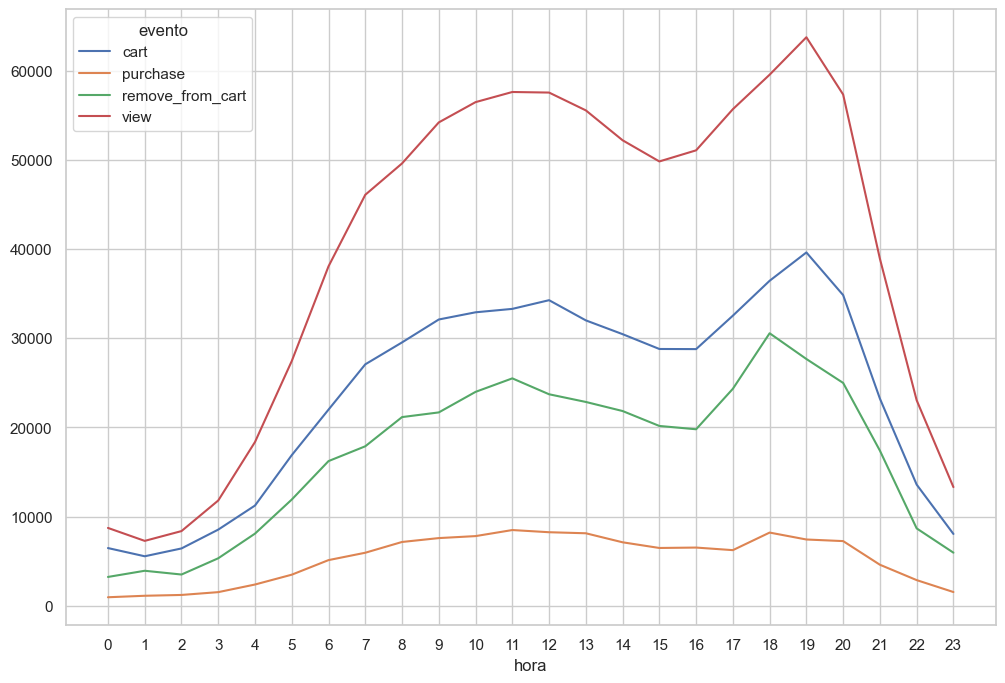

In [32]:
eventos_hora.plot(figsize = (12,8))
plt.xticks(ticks = eventos_hora.index);
plt.show()

Existe una pauta global.

Observamos el mayor número de visualizaciones de 17 a 20 horas.

La tasa de compras presenta una distribución bastante homogénea.

Esto nos justifica crear una variable para obtener el ratio de compras por visita en cada hora.

In [33]:
eventos_hora['compras_visitas'] = eventos_hora.purchase / eventos_hora.view *100
eventos_hora

evento,cart,purchase,remove_from_cart,view,compras_visitas
hora,,,,,
0,6475,962,3238,8731,11.02
1,5555,1128,3930,7280,15.49
2,6433,1220,3509,8378,14.56
3,8544,1535,5331,11807,13.00
4,11242,2389,8095,18365,13.01
5,16890,3491,11913,27438,12.72
6,21993,5125,16223,38055,13.47
7,27069,5951,17883,46072,12.92
8,29526,7158,21156,49587,14.44


Reordenamos las variables

In [34]:
eventos_hora = eventos_hora[['view','cart','remove_from_cart','purchase','compras_visitas']]
eventos_hora

evento,view,cart,remove_from_cart,purchase,compras_visitas
hora,,,,,
0,8731,6475,3238,962,11.02
1,7280,5555,3930,1128,15.49
2,8378,6433,3509,1220,14.56
3,11807,8544,5331,1535,13.00
4,18365,11242,8095,2389,13.01
5,27438,16890,11913,3491,12.72
6,38055,21993,16223,5125,13.47
7,46072,27069,17883,5951,12.92
8,49587,29526,21156,7158,14.44


Visualizamos en gráfico para ver que horas son las que tienen mayor proporción de compras:

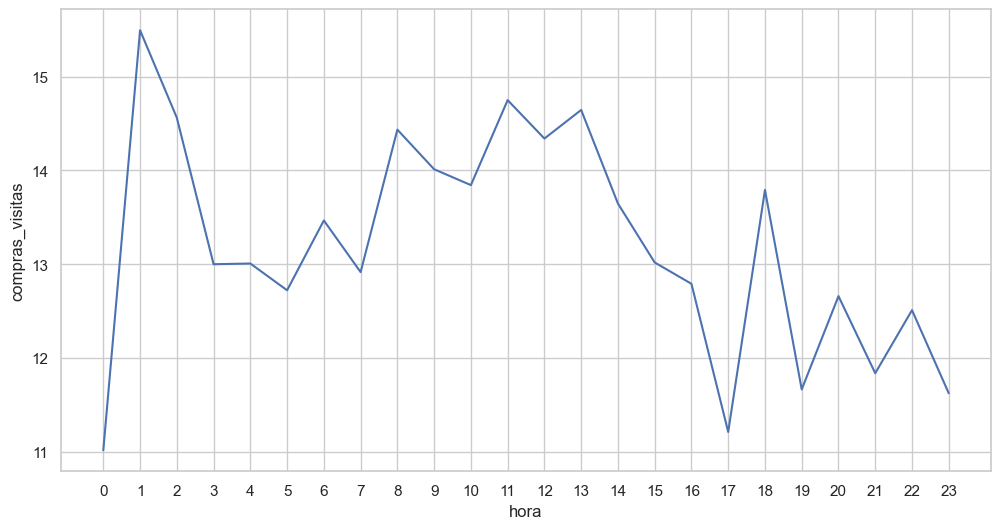

In [35]:
plt.figure(figsize = (12,6))
sns.lineplot(data = eventos_hora, x = eventos_hora.index, y = 'compras_visitas')
plt.xticks(eventos_hora.index);
plt.show()

La tasa de conversión por hora muestra una distribución asimétrica significativa.

A la 1 de la mañana es la mayor tasa de conversión, no significa que sea el mayor número de compras, si no el efecto en que cada visita sale más rentable.

Esta información permite optimizar la inversión en paid media concentrándola en los tramos horarios de mayor rentabilidad por visita.

De tal manera, que contando que tuviesemos un precio constante de tráfico, migrariamos toda la inversión a las horas de mayor conversión por ser más rentables.

Las horas en las que más gente compra son la 1, las 8, de 11 a 13 y a las 18h.

Las horas en las que la gente no compra son las 24, de 3 a 7, de 14 a 17 y de 19 a 23.

Analizamos ahora la distribución absoluta por evento y hora mediante heatmap:

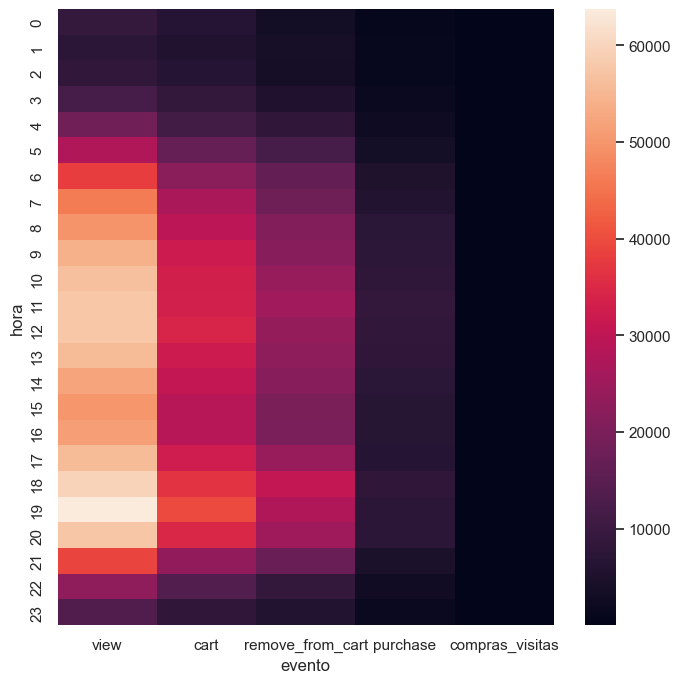

In [36]:
plt.figure(figsize = (8,8))
sns.heatmap(data = eventos_hora);

Al tener cada evento diferente escala, el heatmap no permite comparar patrones entre columnas.

Para solucionarlo usamos tipificación de variables para normalizar y hacer comparables las distribuciones:

In [37]:
def tipificar(variable):
    media = variable.mean()
    dt = variable.std()
    return(variable.apply(lambda x: ( x - media) / dt))

In [38]:
eventos_hora_tip = eventos_hora.apply(tipificar)
eventos_hora_tip

evento,view,cart,remove_from_cart,purchase,compras_visitas
hora,,,,,
0,-1.60,-1.56,-1.63,-1.62,-1.83
1,-1.68,-1.64,-1.54,-1.56,1.91
2,-1.62,-1.56,-1.59,-1.53,1.13
3,-1.45,-1.37,-1.38,-1.41,-0.17
4,-1.11,-1.13,-1.06,-1.09,-0.17
5,-0.65,-0.63,-0.61,-0.68,-0.41
6,-0.10,-0.17,-0.10,-0.07,0.22
7,0.31,0.28,0.09,0.24,-0.24
8,0.49,0.50,0.48,0.69,1.03


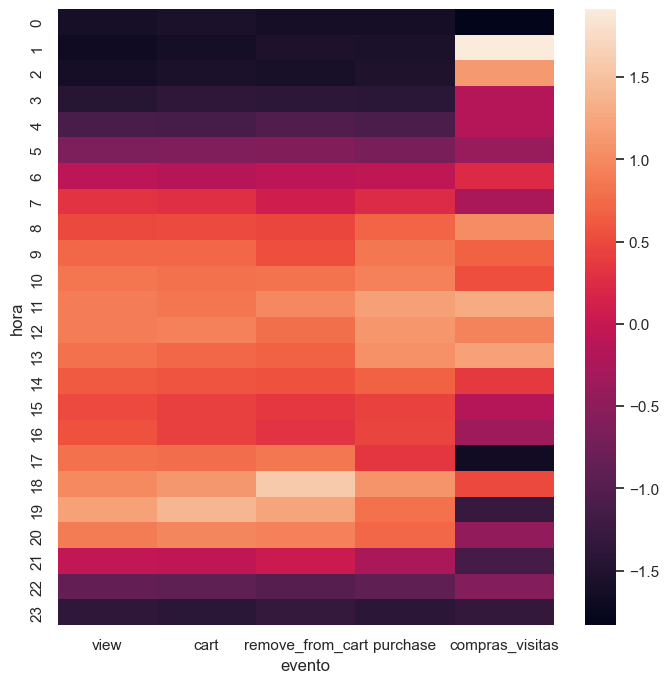

In [39]:
plt.figure(figsize = (8,8))
sns.heatmap(data = eventos_hora_tip);

Analizamos la evolución tipificada por evento para identificar patrones horarios con independencia de escala:

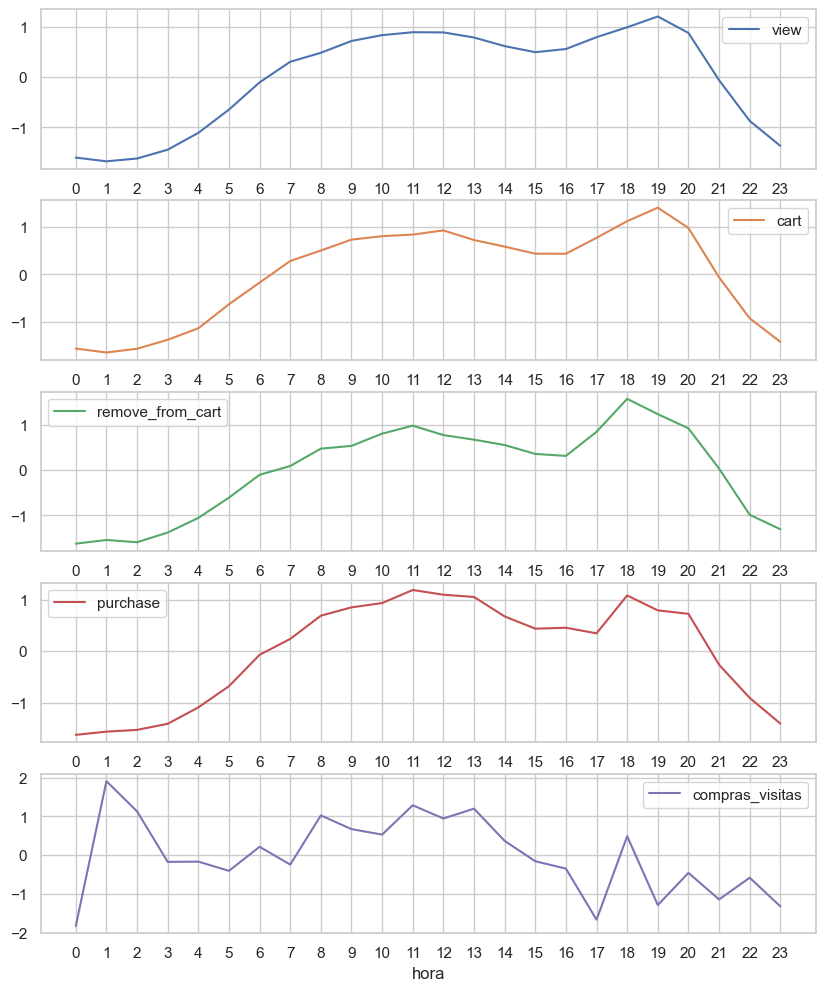

In [40]:
eventos_hora_tip.plot(subplots = True, sharex = False, figsize = (10,12),xticks = eventos_hora_tip.index);

**Conclusiones**:
- **INSIGHT #1**: Todas las métricas se maximizan en las franjas entre las 9 y las 13h y entre las 18 y las 20h.
- Este dato es clave para optimizar la inversión en paid media, tanto en generación de tráfico como en retargeting.
- A la 1 de la mañana se detecta un segmento minoritario de usuarios con alta tasa de conversión, relevante para campañas de retargeting nocturno.

## 1.1.4. ¿Cúal es la media de facturación mensual?

Calculamos la facturación media mensual filtrando los eventos de compra completada:

In [41]:
df.loc[df.evento =='purchase'].groupby('mes').precio.sum().mean()

np.float64(124309.92)

La facturación media mensual es de 124300€.

## 1.4. Segmentación RFM y Life-Time Value: Identificar clientes de alto valor

Analizamos la tendencia semanal para identificar patrones estacionales:

In [42]:
tendencia = df.groupby('evento').resample('W').evento.count().unstack(level = 0)
tendencia

evento,cart,purchase,remove_from_cart,view
fecha,,,,
2019-10-06,31483,4440,14647,36353
2019-10-13,28151,5422,17989,44410
2019-10-20,23920,5033,15303,39486
2019-10-27,25651,5665,18411,40383
2019-11-03,24087,5746,16491,39365
2019-11-10,29142,6663,24008,46177
2019-11-17,25335,5141,17215,41170
2019-11-24,38069,9754,27973,56477
2019-12-01,31994,7493,23106,48883


Ordenamos las columnas:

In [43]:
tendencia = tendencia[['view','cart','remove_from_cart','purchase']]
tendencia

evento,view,cart,remove_from_cart,purchase
fecha,,,,
2019-10-06,36353,31483,14647,4440
2019-10-13,44410,28151,17989,5422
2019-10-20,39486,23920,15303,5033
2019-10-27,40383,25651,18411,5665
2019-11-03,39365,24087,16491,5746
2019-11-10,46177,29142,24008,6663
2019-11-17,41170,25335,17215,5141
2019-11-24,56477,38069,27973,9754
2019-12-01,48883,31994,23106,7493


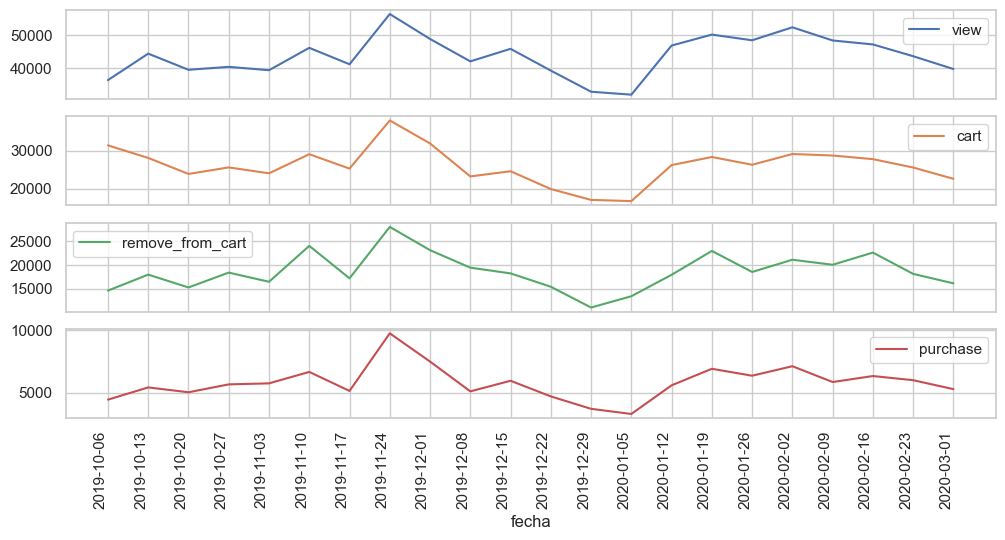

In [44]:
tendencia.plot(subplots = True, figsize = (12,6), sharex = True, xticks= tendencia.index, x_compat=True, rot= 90);

La tendencia es plana en todas las métricas, lo que confirma la necesidad de las acciones de CRO.

Existe un pico significativo en la semana del 24, correspondiente al black friday.

En Navidad se produce un valle, indicando que los consumidores adelantan las compras a noviembre.

Profundizar con granularidad diarira en noviembre y diciembre para analizar el efecto Black Friday.

In [45]:
tendencia_diaria = df.loc['2019-11':'2019-12'].groupby('evento').resample('D').evento.count().unstack(level = 0)
tendencia_diaria

evento,cart,purchase,remove_from_cart,view
fecha,,,,
2019-11-01,3565,709,2810,5352
2019-11-02,3015,912,2124,4857
2019-11-03,3540,755,2622,5583
2019-11-04,4652,676,4854,6248
2019-11-05,4118,753,2711,7213
...,...,...,...,...
2019-12-27,2023,507,1335,4058
2019-12-28,1744,329,1193,3704
2019-12-29,2134,263,1149,3939


In [46]:
tendencia_diaria = tendencia_diaria[['view','cart','remove_from_cart','purchase']]
tendencia_diaria

evento,view,cart,remove_from_cart,purchase
fecha,,,,
2019-11-01,5352,3565,2810,709
2019-11-02,4857,3015,2124,912
2019-11-03,5583,3540,2622,755
2019-11-04,6248,4652,4854,676
2019-11-05,7213,4118,2711,753
...,...,...,...,...
2019-12-27,4058,2023,1335,507
2019-12-28,3704,1744,1193,329
2019-12-29,3939,2134,1149,263


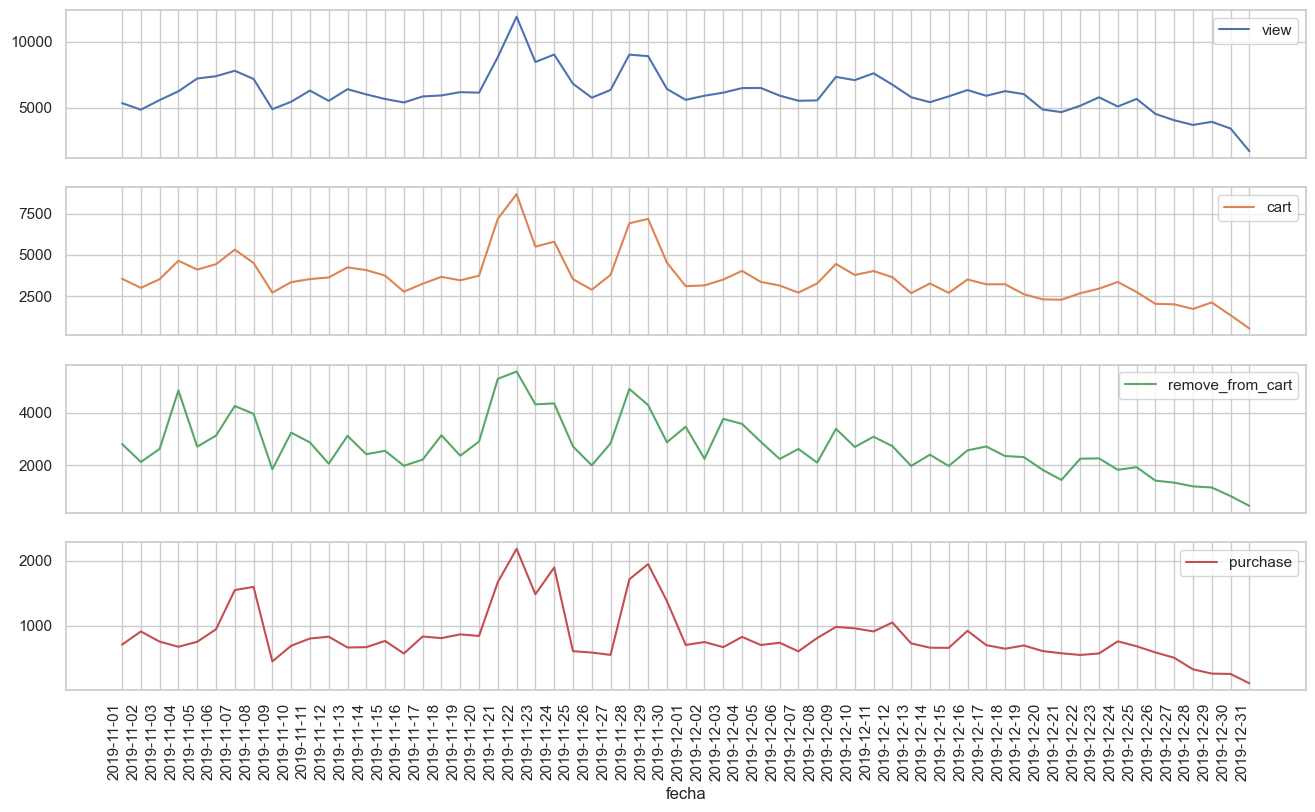

In [47]:
tendencia_diaria.plot(subplots = True, figsize = (16,10), sharex= True, xticks = tendencia_diaria.index, x_compat = True, rot= 90);

**Conclusiones**:
- El pico de ventas coincide con black friday como intuíamos.
- Aún hay un pico mayor unos días antes. El día 22 es posiblemente el inicio de la semana.
- Sorprendentemente los propios días de Navidad tienen una tendencia decreciente, lo que significa que los consumidores claramente han adelantado compras.

Mismo análisis para enero-febrero para identificar patrones post-navideños:

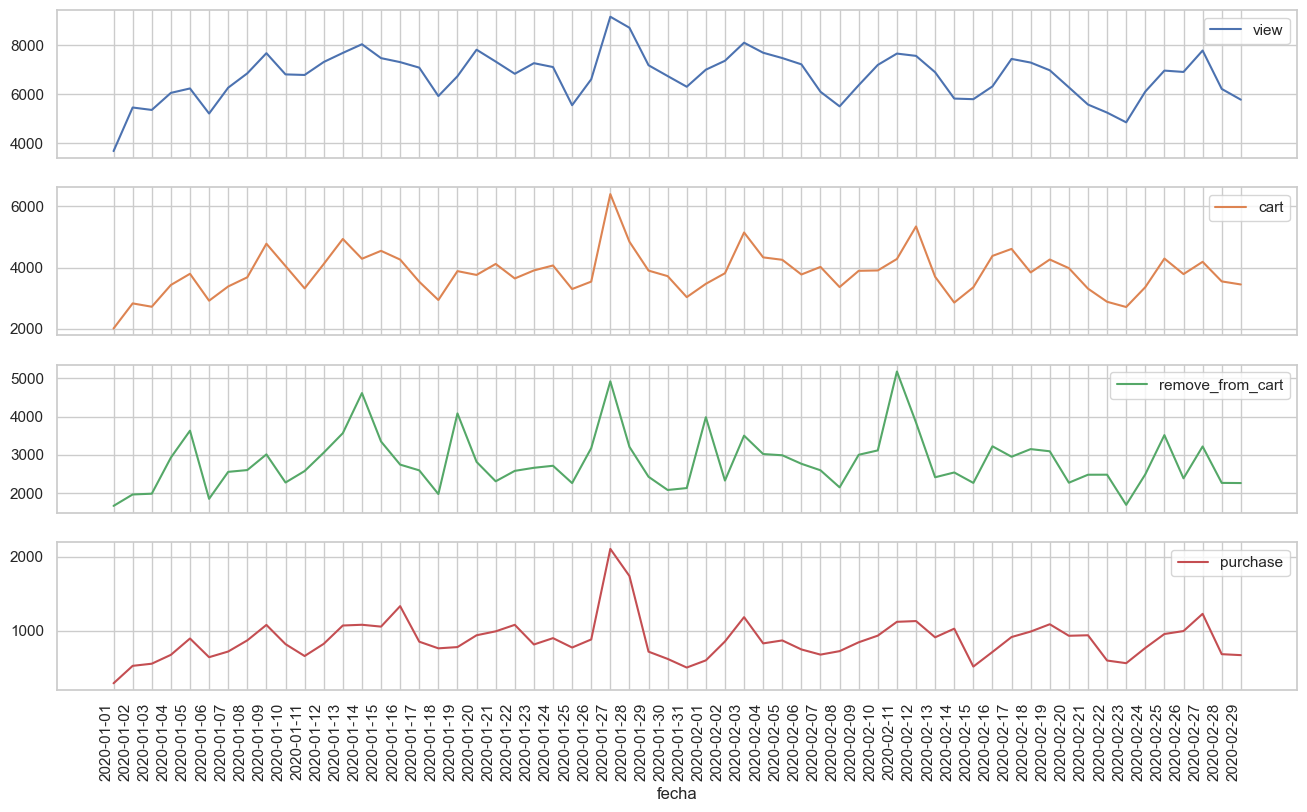

In [48]:
tendencia_diaria = df.loc['2020-01':'2020-02'].groupby('evento').resample('D').evento.count().unstack(level = 0)
tendencia_diaria = tendencia_diaria[['view','cart','remove_from_cart','purchase']]
tendencia_diaria.plot(subplots = True, figsize = (16,10), sharex = True, xticks = tendencia_diaria.index, x_compat=True, rot= 90);

**Conclusiones**:
- Durante la semana de Reyes no se observa pico de ventas. Se alcanza máximo entorno al 9 ó 10 de enero.
- Ni en los días previos de San Valentín se genera un incremento significativo.
- Se detecta un pico de ventas muy pronunciado el 28 de enero, seguramente algún evento local.

**INSIGHT #2**: Invertir mucho en BF. La práctica totalidad del volumen de compras navideño se concentra en la semana del Black Friday

## 1.1.6 Análisis de momentos de la verdad

Identificamos los momentos a nivel día-hora con mayor concentración de compras para optimizar la programación de campañas:

In [49]:
compras_dia_hora = df.loc[df.evento =='purchase'].groupby(['date','hora']).evento.count().unstack(level=0).fillna(0)
compras_dia_hora

date,2019-10-01,2019-10-02,2019-10-03,2019-10-04,2019-10-05,2019-10-06,2019-10-07,2019-10-08,2019-10-09,2019-10-10,...,2020-02-20,2020-02-21,2020-02-22,2020-02-23,2020-02-24,2020-02-25,2020-02-26,2020-02-27,2020-02-28,2020-02-29
hora,,,,,,,,,,,,,,,,,,,,,
0,13.00,18.00,1.00,2.00,0.00,0.00,0.00,0.00,3.00,23.00,...,28.00,0.00,0.00,0.00,0.00,55.00,5.00,40.00,0.00,0.00
1,0.00,0.00,5.00,0.00,4.00,24.00,3.00,0.00,16.00,0.00,...,0.00,5.00,0.00,2.00,21.00,11.00,0.00,5.00,26.00,33.00
2,0.00,0.00,0.00,24.00,0.00,0.00,0.00,18.00,4.00,18.00,...,9.00,0.00,0.00,10.00,0.00,34.00,0.00,0.00,0.00,8.00
3,0.00,24.00,10.00,0.00,0.00,26.00,2.00,20.00,16.00,55.00,...,0.00,14.00,13.00,0.00,5.00,15.00,0.00,10.00,0.00,0.00
4,15.00,0.00,45.00,27.00,3.00,24.00,12.00,46.00,56.00,0.00,...,6.00,22.00,34.00,17.00,7.00,16.00,10.00,148.00,16.00,0.00
5,49.00,9.00,6.00,17.00,1.00,14.00,21.00,10.00,0.00,43.00,...,23.00,8.00,28.00,0.00,14.00,103.00,6.00,48.00,11.00,3.00
6,23.00,34.00,18.00,10.00,10.00,13.00,38.00,35.00,14.00,12.00,...,7.00,22.00,5.00,46.00,26.00,20.00,94.00,26.00,58.00,35.00
7,26.00,60.00,26.00,54.00,58.00,20.00,63.00,27.00,26.00,59.00,...,98.00,67.00,52.00,10.00,30.00,23.00,30.00,53.00,38.00,65.00
8,28.00,71.00,129.00,49.00,20.00,37.00,27.00,41.00,89.00,62.00,...,30.00,95.00,35.00,52.00,30.00,17.00,120.00,80.00,67.00,25.00


Para poder visualizarlo e interpretarlo creamos un gráfico.

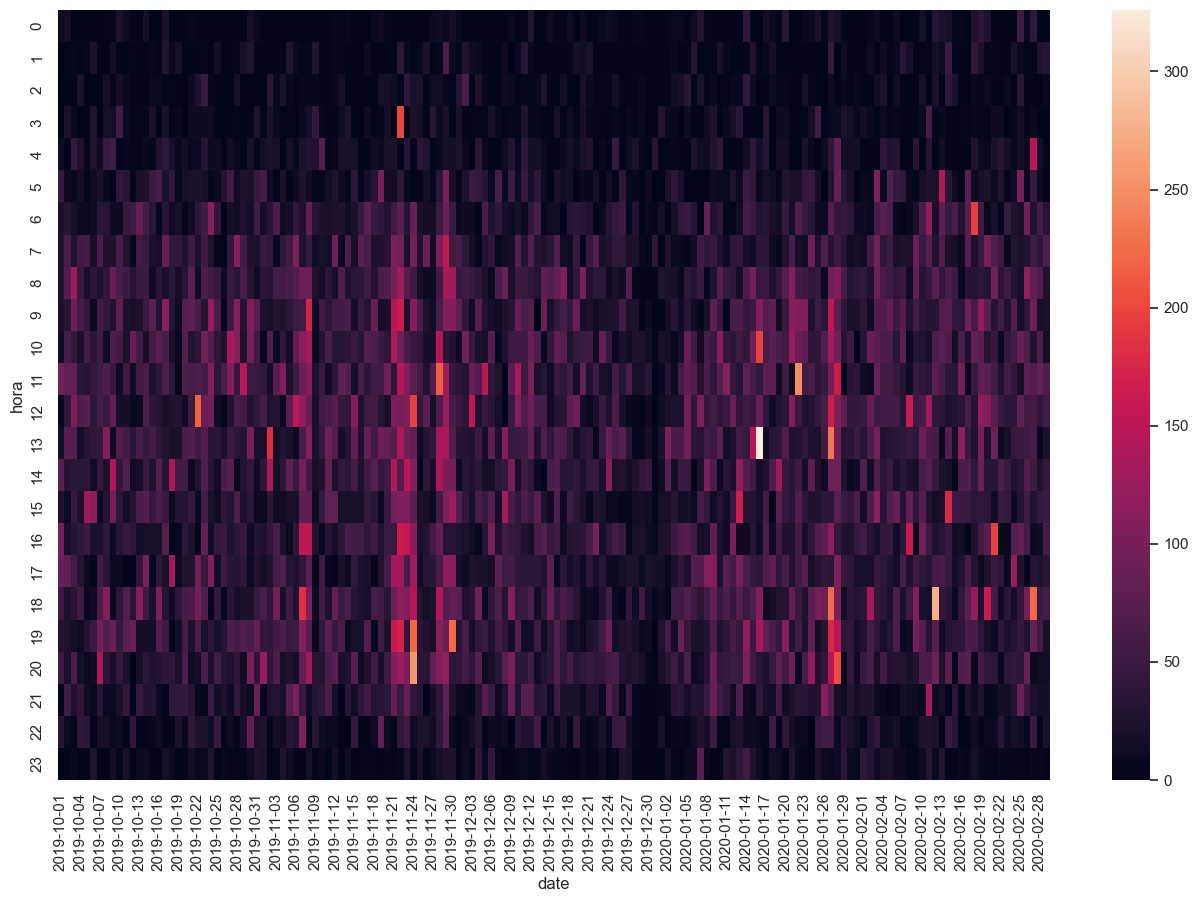

In [50]:
plt.figure(figsize = (16,10))
sns.heatmap(compras_dia_hora);

El heatmap muestra la concentración de compras por día y hora. 

Los puntos más claros indican los momentos de mayor volumen de ventas 
destacando el 17 de enero a las 13h como el pico máximo del período analizado.

## 1.2. Análisis de Base de Clientes: Segmentación y Comportamiento

Construimos el dataframe de clientes agregando a nivel de usuario, 
considerando únicamente los eventos de compra completada.

In [51]:
df.loc[df.evento == 'purchase'].groupby('usuario').agg({'producto':'count',
                                                        'sesion':'nunique',
                                                        'precio':'mean',
                                                        'date':'max'})

,producto,sesion,precio,date
usuario,,,,
25392526,3,1,7.38,2019-12-18
27756757,1,1,20.63,2020-01-27
50748978,9,1,1.11,2019-12-14
52747911,3,1,7.67,2019-10-10
65241811,5,1,8.36,2019-11-11
...,...,...,...,...
621995551,5,1,2.09,2020-02-29
622021687,1,1,13.33,2020-02-29
622041514,3,1,0.63,2020-02-29


Guardamos el dataframe de clientes para su uso en análisis posteriores:

In [52]:
clientes = df.loc[df.evento == 'purchase'].groupby('usuario').agg({'producto':'count',
                                                        'sesion':'nunique',
                                                        'precio':'mean',
                                                        'date':'max'})

Renombramos las columnas

In [53]:
clientes.columns = ['productos_tot_num','compras_tot_num','precio_medio_prod','ult_compra']
clientes

,productos_tot_num,compras_tot_num,precio_medio_prod,ult_compra
usuario,,,,
25392526,3,1,7.38,2019-12-18
27756757,1,1,20.63,2020-01-27
50748978,9,1,1.11,2019-12-14
52747911,3,1,7.67,2019-10-10
65241811,5,1,8.36,2019-11-11
...,...,...,...,...
621995551,5,1,2.09,2020-02-29
622021687,1,1,13.33,2020-02-29
622041514,3,1,0.63,2020-02-29


Añadimos el gasto total y los productos por compra como variables derivadas:

In [54]:
clientes['gasto_tot'] = clientes.productos_tot_num * clientes.precio_medio_prod
clientes['productos_por_compra'] = clientes.productos_tot_num / clientes.compras_tot_num
clientes

,productos_tot_num,compras_tot_num,precio_medio_prod,ult_compra,gasto_tot,productos_por_compra
usuario,,,,,,
25392526,3,1,7.38,2019-12-18,22.14,3.00
27756757,1,1,20.63,2020-01-27,20.63,1.00
50748978,9,1,1.11,2019-12-14,10.01,9.00
52747911,3,1,7.67,2019-10-10,23.02,3.00
65241811,5,1,8.36,2019-11-11,41.79,5.00
...,...,...,...,...,...,...
621995551,5,1,2.09,2020-02-29,10.46,5.00
622021687,1,1,13.33,2020-02-29,13.33,1.00
622041514,3,1,0.63,2020-02-29,1.90,3.00


## 1.2.1. ¿Cómo se distribuyen los clientes en cuanto a gasto?

Analizamos ahora la frecuencia de compra para encontrar el tercer INSIGHT

Tenemos que distinguir entre clientes que compran mucho o los que compran menos pero con alto importe.

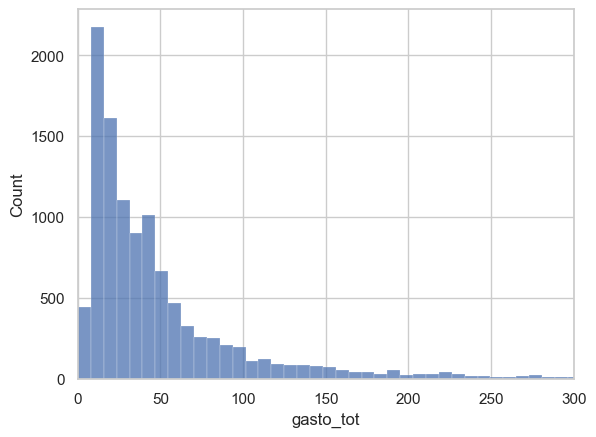

In [55]:
sns.histplot (data = clientes, x = 'gasto_tot', bins = 200)
plt.xlim([0,300]);

La distribución de gasto muestra una cola larga típica en e-commerce.

La mayoría de clientes concentra su gasto por debajo de 50€.

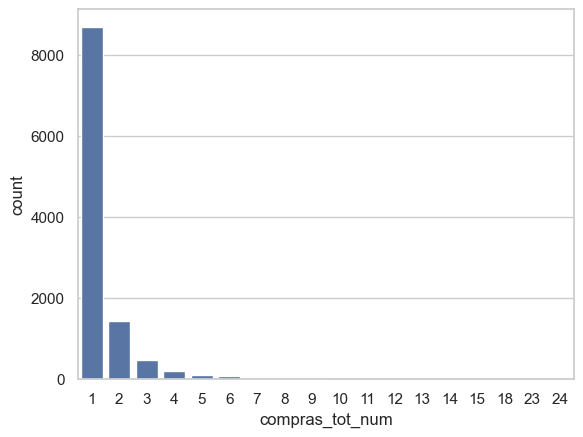

In [56]:
sns.countplot(data = clientes, x= 'compras_tot_num');

**INSIGHT #3**: La gran mayoría de clientes hace sólo una compra.

Esto es de extrema relevancia. Porque si consiguiesemos que cada cliente realizara 2 compras, podríamos doblar ventas.

## 1.2.3. ¿Cuántos productos compra un cliente de media en cada compra?

Calculamos la distribución de productos por compra para identificar el comportamiento típico del cliente:

In [57]:
clientes.productos_por_compra.describe()

count          11040.00
mean               7.79
std                9.49
min                1.00
25%                3.00
50%                5.00
75%               10.00
max              219.00
Name: productos_por_compra, dtype: float64

Cada cliente compra de media 7 productos, tenemos una desviación típica de 9.49 superior a la media.

Tenemos un máximo de 219 productos que no será pauta normal. Por lo que el dato de la mediana será más correcto.

Por tanto, diremos que cada cliente compra de media 5 productos.

**INSIGHT #4**: Como el percentil 75% es de 10, existe suficiente elasticidad para mejorar la mediana.

Ya que un 25% de los clientes compra más de 10 productos en la misma compra.

Podrían añadirse sistemas de recomendación en el momento de la compra.

## 1.2.4. ¿Qué clientes nos han generado más ingresos?

Identificamos los mejores clientes:

In [58]:
clientes.nlargest(n= 10, columns = 'gasto_tot')

,productos_tot_num,compras_tot_num,precio_medio_prod,ult_compra,gasto_tot,productos_por_compra
usuario,,,,,,
573823111,268,2,5.82,2020-02-21,1559.21,134.00
539751397,236,13,6.16,2020-02-19,1453.37,18.15
556579890,506,4,2.75,2020-02-27,1392.45,126.50
442763940,195,8,6.37,2019-12-23,1241.53,24.38
561592095,94,3,11.81,2019-10-31,1109.70,31.33
527739278,244,13,4.39,2020-02-16,1071.00,18.77
527806771,195,13,4.86,2020-02-20,948.01,15.00
430220205,190,6,4.99,2020-02-29,947.30,31.67
491009486,219,1,4.32,2020-02-12,946.20,219.00


In [59]:
clientes.gasto_tot.describe()

count          11040.00
mean              56.30
std               81.73
min                0.13
25%               16.22
50%               32.74
75%               60.30
max             1559.21
Name: gasto_tot, dtype: float64

La mediana es de 32€.

**INSIGHT #5**: Hay clientes que gastan 30 veces más que la mediana.

Deben ser clientes profesionales que comprar para vender a nivel local.

Podrían aplicarse métodos de descuento por cliente y fidelización.

In [60]:
clientes

,productos_tot_num,compras_tot_num,precio_medio_prod,ult_compra,gasto_tot,productos_por_compra
usuario,,,,,,
25392526,3,1,7.38,2019-12-18,22.14,3.00
27756757,1,1,20.63,2020-01-27,20.63,1.00
50748978,9,1,1.11,2019-12-14,10.01,9.00
52747911,3,1,7.67,2019-10-10,23.02,3.00
65241811,5,1,8.36,2019-11-11,41.79,5.00
...,...,...,...,...,...,...
621995551,5,1,2.09,2020-02-29,10.46,5.00
622021687,1,1,13.33,2020-02-29,13.33,1.00
622041514,3,1,0.63,2020-02-29,1.90,3.00


## 1.2.5. ¿Cual es la supervivencia de los clientes?

Con 5 meses de histórico construimos un análisis de cohortes a 3 meses vista, definiendo 3 cohortes comparables.

Preparamos un dataframe solo con compradores y con las variables usuario y mes.

In [61]:
c = df.loc[df.evento == 'purchase',['usuario','mes']]
c

,usuario,mes
fecha,,
2019-10-01 00:26:49,536128518,10
2019-10-01 00:26:49,536128518,10
2019-10-01 00:26:49,536128518,10
2019-10-01 00:26:49,536128518,10
2019-10-01 00:26:49,536128518,10
...,...,...
2020-02-29 22:29:19,622065819,2
2020-02-29 22:29:19,622065819,2
2020-02-29 22:29:19,622065819,2


Pasamos los meses a columnas

In [62]:
c = pd.crosstab(c.usuario,c.mes).reset_index()
c

mes,usuario,1,2,10,11,12
0,25392526,0,0,0,0,3
1,27756757,1,0,0,0,0
2,50748978,0,0,0,0,9
3,52747911,0,0,3,0,0
4,65241811,0,0,0,5,0
...,...,...,...,...,...,...
11035,621995551,0,5,0,0,0
11036,622021687,0,1,0,0,0
11037,622041514,0,3,0,0,0
11038,622042698,0,3,0,0,0


A continuación renombramos y eliminamos el usuario, ya que no necesitamos esos números.

In [ ]:
c.columns = ['usuario','c4','c5','c1','c2','c3']
c.drop(columns = 'usuario', inplace = True)
c

,c4,c5,c1,c2,c3
0,0,0,0,0,3
1,1,0,0,0,0
2,0,0,0,0,9
3,0,0,3,0,0
4,0,0,0,5,0
...,...,...,...,...,...
11035,0,5,0,0,0
11036,0,1,0,0,0
11037,0,3,0,0,0
11038,0,3,0,0,0


La primera cohorte será la del mes 2, ya que queremos seleccionar "nuevos" clientes (que no aparecieran el mes anterior).

Para cada cohorte hacemos estos tres pasos:
 1. Seleccionar clientes nuevos en cada cohorte (ausentes en el mes anterior).
 2. Binarizar la variable de compra por mes.
 3. Calcular la tasa de supervivencia mensual.

El análisis está condicionado por la limitación de 5 meses de histórico disponible.

In [64]:
c2 = c.loc[(c.c1 == 0) & ( c.c2 > 0)]
c2

,c4,c5,c1,c2,c3
4,0,0,0,5,0
6,0,0,0,10,0
8,0,0,0,27,17
9,0,0,0,3,0
13,0,0,0,4,0
...,...,...,...,...,...
7702,0,0,0,5,0
7703,0,5,0,2,0
7705,0,0,0,1,0
7708,0,0,0,5,6


Pasamos a un DF binario ya que solo nos importa si ese cliente ha comprado o no en cada mes.

In [65]:
def binarizar(variable):
    variable = variable.transform(lambda x:1 if (x>0) else 0)
    return(variable)

In [66]:
c2_b = c2.apply(binarizar)
c2_b

,c4,c5,c1,c2,c3
4,0,0,0,1,0
6,0,0,0,1,0
8,0,0,0,1,1
9,0,0,0,1,0
13,0,0,0,1,0
...,...,...,...,...,...
7702,0,0,0,1,0
7703,0,1,0,1,0
7705,0,0,0,1,0
7708,0,0,0,1,1


Calculamos el porcentaje de clientes de esta cohorte que han seguido comprando en los siguientes meses.

In [67]:
c2_f = c2_b.sum() / c2_b.shape[0]
c2_f = c2_f.sort_index()
c2_f

c1              0.00
c2              1.00
c3              0.10
c4              0.10
c5              0.08
dtype: float64

In [68]:
c2_b = c2_b.mean().sort_index()

C1 no aplica tiene que ser 0. c2 es 100% porque es donde empezamos.

c3 es un 10%, esto significa que sólo el 10% de todos los clientes del mes 2 siguen comprando el mes 3

El mes 4 también es un 10% y el 5 reduce a 8%.

Esto será importante para ver dónde incrementar ingresos.

Replicamos ahora todo el proceso para el cohorte 3

In [69]:
c3 = c.loc[(c.c2 == 0) & ( c.c3 > 0)]
c3_b = c3.apply(binarizar)
c3_b = c3_b.mean().sort_index()
c3_b['c1'] = 0
c3_b

c1              0.00
c2              0.00
c3              1.00
c4              0.10
c5              0.08
dtype: float64

Cohorte 4:

In [70]:
c4 = c.loc[(c.c3 == 0) & ( c.c4 > 0)]
c4_b = c4.apply(binarizar)
c4_b = c4_b.mean().sort_index()
c4_b['c1'] = 0
c4_b['c2'] = 0
c4_b

c1              0.00
c2              0.00
c3              0.00
c4              1.00
c5              0.12
dtype: float64

Consolidamos las tres cohortes en un único dataframe para su visualización:

In [71]:
cohortes = pd.DataFrame({'c2':c2_b,
             'c3':c3_b,
             'c4':c4_b})
cohortes

,c2,c3,c4
c1,0.00,0.00,0.00
c2,1.00,0.00,0.00
c3,0.10,1.00,0.00
c4,0.10,0.10,1.00
c5,0.08,0.08,0.12


Aquí encontramos un error metodológico por la ventana temporal que tenemos. Aquí sería poner condiciones de los meses anteriores.

Otra opción es sobreescribir ese registro. Ponemos en la celda anterior c3_b['c1']=0

In [72]:
cohortes = cohortes.drop(index = 'c1').T
cohortes

,c2,c3,c4,c5
c2,1.00,0.10,0.10,0.08
c3,0.00,1.00,0.10,0.08
c4,0.00,0.00,1.00,0.12


La cohorte 2 muestra retenciones del 10% en mes 3, 10% en mes 4 y 8% en mes 5.

La cohorte 3 que empieza en mes 3 y tiene un 10% de supervivencia en mes 4 y un 8% en mes 5.

Y la cohorte 4 que empieza en mes 4 y tiene un 12% de supervivencia al mes siguiente.

La consistencia entre las tres cohortes confirma la solidez del patrón identificado:

INSIGHT #6: el 90% de los nuevos clientes de un mes no sigue comprando los meses posteriores.

Visualizamos las tasas de retención por cohorte mediante heatmap:

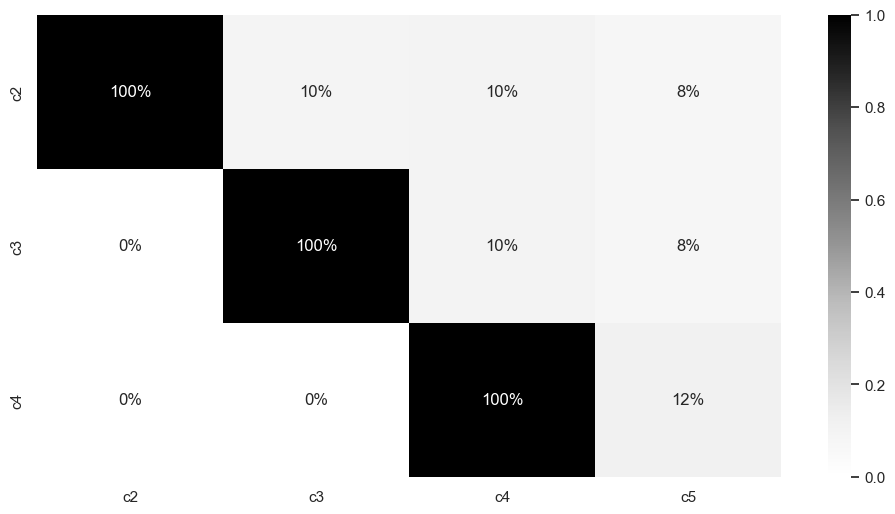

In [73]:
plt.figure(figsize = (12,6))
sns.heatmap(data = cohortes, annot = True, fmt= '.0%', cmap = 'Greys');
plt.show()

El resultado es un entregable claro con las tasas de supervivencia por cohorte. 

Existen librerías especializadas en Python para análisis de supervivencia más avanzados.

## 1.2.6. ¿Cuál es el LTV de los clientes?

El Lifetime Value (LTV) representa el ingreso total esperado por cliente durante su ciclo de vida, y es un indicador clave para dimensionar la inversión en captación y retención.

Partiendo del INSIGHT #6, calculamos el LTV enfocándonos en la cohorte 2 (nuevos en noviembre), utilizando la variable gasto_tot como proxy del valor por cliente.

Extraemos el listado de usuarios de esta cohorte:

In [ ]:
df.loc[(df.evento == 'purchase') & (df.mes !=10) & (df.mes == 11)]

,usuario,sesion,categoria,evento,producto,precio,date,año,mes,dia,hora,minuto,segundo,festivo,black_firday,san_valentin
fecha,,,,,,,,,,,,,,,,
2019-11-01 04:56:55,549319657,04189079-86de-40ad-9181-c35684327306,1487580006895846315,purchase,4497,3.11,2019-11-01,2019,11,1,4,56,55,0,0,0
2019-11-01 04:56:55,549319657,04189079-86de-40ad-9181-c35684327306,1487580009445982239,purchase,5854897,0.32,2019-11-01,2019,11,1,4,56,55,0,0,0
2019-11-01 04:56:55,549319657,04189079-86de-40ad-9181-c35684327306,1487580006551913373,purchase,5587740,0.87,2019-11-01,2019,11,1,4,56,55,0,0,0
2019-11-01 04:56:55,549319657,04189079-86de-40ad-9181-c35684327306,1487580007306888126,purchase,5620922,2.22,2019-11-01,2019,11,1,4,56,55,0,0,0
2019-11-01 04:56:55,549319657,04189079-86de-40ad-9181-c35684327306,1487580007717929935,purchase,5645768,1.59,2019-11-01,2019,11,1,4,56,55,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-30 23:09:47,553588523,cacd491b-ce8b-4b2c-bb0d-880303fd8434,1897124478404526487,purchase,5813417,5.56,2019-11-30,2019,11,30,23,9,47,0,0,0
2019-11-30 23:09:47,553588523,cacd491b-ce8b-4b2c-bb0d-880303fd8434,1783999068909863670,purchase,5814713,4.37,2019-11-30,2019,11,30,23,9,47,0,0,0
2019-11-30 23:09:47,553588523,cacd491b-ce8b-4b2c-bb0d-880303fd8434,1487580007675986893,purchase,5833325,1.59,2019-11-30,2019,11,30,23,9,47,0,0,0


In [ ]:
df.loc[(df.evento == 'purchase') & (df.mes !=10) & (df.mes == 11), 'usuario']

fecha
2019-11-01 04:56:55    549319657
2019-11-01 04:56:55    549319657
2019-11-01 04:56:55    549319657
2019-11-01 04:56:55    549319657
2019-11-01 04:56:55    549319657
                         ...    
2019-11-30 23:09:47    553588523
2019-11-30 23:09:47    553588523
2019-11-30 23:09:47    553588523
2019-11-30 23:09:47    553588523
2019-11-30 23:09:47    553588523
Name: usuario, Length: 30723, dtype: int64

Ahora pasamos estos usuarios a una lista para poder filtrarlos.

La nombramos maestro_ltv

In [76]:
maestro_ltv = df.loc[(df.evento == 'purchase') & (df.mes !=10) & (df.mes == 11), 'usuario'].to_list()
maestro_ltv

[549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 549319657,
 566322866,
 566322866,
 566322866,
 566322866,
 566322866,
 566322866,
 566322866,
 566322866,
 491040843,
 491040843,
 491040843,
 491040843,
 491040843,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 448281768,
 483964876,
 483964876,
 483964876,
 483964876,
 483964876,
 483964876,
 483964876,
 497964079,
 497964079,
 497964079,
 497964079,
 566332999,
 551059137,
 539216862,
 539216862,
 539216862,
 539216862,
 539

In [77]:
clientes

,productos_tot_num,compras_tot_num,precio_medio_prod,ult_compra,gasto_tot,productos_por_compra
usuario,,,,,,
25392526,3,1,7.38,2019-12-18,22.14,3.00
27756757,1,1,20.63,2020-01-27,20.63,1.00
50748978,9,1,1.11,2019-12-14,10.01,9.00
52747911,3,1,7.67,2019-10-10,23.02,3.00
65241811,5,1,8.36,2019-11-11,41.79,5.00
...,...,...,...,...,...,...
621995551,5,1,2.09,2020-02-29,10.46,5.00
622021687,1,1,13.33,2020-02-29,13.33,1.00
622041514,3,1,0.63,2020-02-29,1.90,3.00


In [78]:
clientes.loc[clientes.index.isin(maestro_ltv)]

,productos_tot_num,compras_tot_num,precio_medio_prod,ult_compra,gasto_tot,productos_por_compra
usuario,,,,,,
65241811,5,1,8.36,2019-11-11,41.79,5.00
80577370,10,2,10.62,2019-11-29,106.24,5.00
88211255,22,4,4.86,2020-02-25,106.87,5.50
93279832,44,2,3.19,2019-12-19,140.51,22.00
94390236,3,1,9.73,2019-11-07,29.20,3.00
...,...,...,...,...,...,...
579798049,5,1,2.10,2019-11-30,10.52,5.00
579813390,7,2,2.98,2020-02-04,20.83,3.50
579834429,1,1,27.14,2019-11-30,27.14,1.00


Aquí nos hemos quedado con 3105 clientes, que son los nuevos en noviembre.

De la cohorte dos y los guardamos como clientes_ltv:

In [79]:
clientes_ltv= clientes.loc[clientes.index.isin(maestro_ltv)]

Calculamos el LTV a cuatro meses:

In [80]:
clientes_ltv.gasto_tot.describe()

count           3105.00
mean              79.62
std              113.62
min                0.13
25%               20.29
50%               41.49
75%               90.00
max             1453.37
Name: gasto_tot, dtype: float64

Vemos que el gasto medio es 79€ pero hay un máximo de 1453 que no sería representativo de un cliente medio.

Si no queremos considerarlo ni eliminarlos, sería más idóneo utilizar la mediana, es decir 41,50€.

INSIGHT #7: LTV medio de cada cliente a 4 meses es de 41.50€.

Este valor permite estimar el CPA máximo recomendable para campañas de captación.

Aplicar las acciones de CRO permitirá incrementar LTV y por tanto el CPZ, siendo una ventaja estratégica muy importante.

# 2. SEGMENTACIÓN RFM

La segmentación RFM clasifica clientes en función de su comportamiento de compra 
utilizando tres dimensiones disponibles en cualquier negocio:

- Recency: ult_compra
- Frequency: compras_tot_num
- Monetary: gasto_tot

Cada dimensión se discretiza en quintiles. La Recency requiere una transformación 
previa a variable numérica antes de discretizar.

In [81]:
clientes

,productos_tot_num,compras_tot_num,precio_medio_prod,ult_compra,gasto_tot,productos_por_compra
usuario,,,,,,
25392526,3,1,7.38,2019-12-18,22.14,3.00
27756757,1,1,20.63,2020-01-27,20.63,1.00
50748978,9,1,1.11,2019-12-14,10.01,9.00
52747911,3,1,7.67,2019-10-10,23.02,3.00
65241811,5,1,8.36,2019-11-11,41.79,5.00
...,...,...,...,...,...,...
621995551,5,1,2.09,2020-02-29,10.46,5.00
622021687,1,1,13.33,2020-02-29,13.33,1.00
622041514,3,1,0.63,2020-02-29,1.90,3.00


Discretizamos la variable en quintiles con pd.cut:

In [82]:
clientes.compras_tot_num.transform(lambda x: pd.cut(x,5, labels = False))

usuario
25392526     0
27756757     0
50748978     0
52747911     0
65241811     0
            ..
621995551    0
622021687    0
622041514    0
622042698    0
622065819    0
Name: compras_tot_num, Length: 11040, dtype: int64

In [83]:
clientes.compras_tot_num.transform(lambda x: pd.cut(x,5, labels = False)).value_counts()

compras_tot_num
0    10886
1      137
2       11
3        4
4        2
Name: count, dtype: int64

In [84]:
clientes.compras_tot_num.transform(lambda x: pd.cut(x,5, labels = False)) +1

usuario
25392526     1
27756757     1
50748978     1
52747911     1
65241811     1
            ..
621995551    1
622021687    1
622041514    1
622042698    1
622065819    1
Name: compras_tot_num, Length: 11040, dtype: int64

El score F comienza en 1 y se almacena como variable en el dataframe de clientes:

In [85]:
clientes['F'] = clientes.compras_tot_num.transform(lambda x: pd.cut(x,5, labels = False)) + 1
clientes

,productos_tot_num,compras_tot_num,precio_medio_prod,ult_compra,gasto_tot,productos_por_compra,F
usuario,,,,,,,
25392526,3,1,7.38,2019-12-18,22.14,3.00,1
27756757,1,1,20.63,2020-01-27,20.63,1.00,1
50748978,9,1,1.11,2019-12-14,10.01,9.00,1
52747911,3,1,7.67,2019-10-10,23.02,3.00,1
65241811,5,1,8.36,2019-11-11,41.79,5.00,1
...,...,...,...,...,...,...,...
621995551,5,1,2.09,2020-02-29,10.46,5.00,1
622021687,1,1,13.33,2020-02-29,13.33,1.00,1
622041514,3,1,0.63,2020-02-29,1.90,3.00,1


Verificamos la correcta asignación de scores por grupo:

In [86]:
clientes.groupby('F').compras_tot_num.mean()

F
1              1.31
2              7.06
3             12.00
4             16.50
5             23.50
Name: compras_tot_num, dtype: float64

Calculamos el score Monetary a partir del gasto total:

In [87]:
clientes['M'] = clientes.gasto_tot.transform(lambda x: pd.cut(x,5, labels = False)) +1
clientes.groupby('M').gasto_tot.mean()

M
1             48.36
2            410.98
3            765.18
4           1043.96
5           1468.34
Name: gasto_tot, dtype: float64

Calculamos la actualización:

No podemos hacerla con la fecha de última compra. Por tanto necesitamos un paso intermedio para construir una variable numérica.

In [88]:
mas_reciente = clientes.ult_compra.max()
mas_reciente

datetime.date(2020, 2, 29)

Para transformar esa última fecha en un número, podemos crear la diferencia entre esa última fecha y la que tiene en el dataset y la última compra.

In [89]:
clientes['ult_compra_dias'] = clientes.ult_compra.transform(lambda x: mas_reciente - x)
clientes

,productos_tot_num,compras_tot_num,precio_medio_prod,ult_compra,gasto_tot,productos_por_compra,F,M,ult_compra_dias
usuario,,,,,,,,,
25392526,3,1,7.38,2019-12-18,22.14,3.00,1,1,73 days
27756757,1,1,20.63,2020-01-27,20.63,1.00,1,1,33 days
50748978,9,1,1.11,2019-12-14,10.01,9.00,1,1,77 days
52747911,3,1,7.67,2019-10-10,23.02,3.00,1,1,142 days
65241811,5,1,8.36,2019-11-11,41.79,5.00,1,1,110 days
...,...,...,...,...,...,...,...,...,...
621995551,5,1,2.09,2020-02-29,10.46,5.00,1,1,0 days
622021687,1,1,13.33,2020-02-29,13.33,1.00,1,1,0 days
622041514,3,1,0.63,2020-02-29,1.90,3.00,1,1,0 days


Revisamos que tipo de variable está creando

In [90]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11040 entries, 25392526 to 622065819
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype          
---  ------                --------------  -----          
 0   productos_tot_num     11040 non-null  int64          
 1   compras_tot_num       11040 non-null  int64          
 2   precio_medio_prod     11040 non-null  float64        
 3   ult_compra            11040 non-null  object         
 4   gasto_tot             11040 non-null  float64        
 5   productos_por_compra  11040 non-null  float64        
 6   F                     11040 non-null  int64          
 7   M                     11040 non-null  int64          
 8   ult_compra_dias       11040 non-null  timedelta64[ns]
dtypes: float64(3), int64(4), object(1), timedelta64[ns](1)
memory usage: 862.5+ KB


Vemos que es un timedelta64. Es un tipo de datos temporal y queremos una variable numérica.

Usamos el assesor de days

In [91]:
clientes['ult_compra_dias'] = clientes.ult_compra_dias.dt.days
clientes

,productos_tot_num,compras_tot_num,precio_medio_prod,ult_compra,gasto_tot,productos_por_compra,F,M,ult_compra_dias
usuario,,,,,,,,,
25392526,3,1,7.38,2019-12-18,22.14,3.00,1,1,73
27756757,1,1,20.63,2020-01-27,20.63,1.00,1,1,33
50748978,9,1,1.11,2019-12-14,10.01,9.00,1,1,77
52747911,3,1,7.67,2019-10-10,23.02,3.00,1,1,142
65241811,5,1,8.36,2019-11-11,41.79,5.00,1,1,110
...,...,...,...,...,...,...,...,...,...
621995551,5,1,2.09,2020-02-29,10.46,5.00,1,1,0
622021687,1,1,13.33,2020-02-29,13.33,1.00,1,1,0
622041514,3,1,0.63,2020-02-29,1.90,3.00,1,1,0


Ya tenemos los días, por tanto tenemos que discretizar la variable

In [92]:
clientes['R'] = clientes.ult_compra_dias.transform(lambda x: pd.cut(x,5, labels = False)) + 1
clientes.groupby('R').ult_compra_dias.mean()

R
1             14.62
2             43.04
3             75.94
4            103.85
5            135.91
Name: ult_compra_dias, dtype: float64

En el valor 1 sale que esos clientes de media hace 14 días que no compran.

Y en valor 5 sale que hace 136 días de media que no compran.

Normalmente el mejor resultado lo obtenemos en 5, por lo que podemos transformar restándolos a 6.

In [93]:
clientes['R'] = 6 - clientes['R']
clientes.groupby('R').ult_compra_dias.mean()

R
1            135.91
2            103.85
3             75.94
4             43.04
5             14.62
Name: ult_compra_dias, dtype: float64

El siguiente paso es crear una variable que unifique las tres cosas:

Una variable Valor que sea la suma de cada una

Y otra variable que haga la concatenación registro a registro, lo que será más óptimo con un apply.

In [94]:
clientes['valor'] = clientes.R + clientes.F + clientes.M
clientes['RFM'] = clientes.apply(lambda x: str(x.R) + str(x.F) + str(x.M), axis = 1)
clientes

,productos_tot_num,compras_tot_num,precio_medio_prod,ult_compra,gasto_tot,productos_por_compra,F,M,ult_compra_dias,R,valor,RFM
usuario,,,,,,,,,,,,
25392526,3,1,7.38,2019-12-18,22.14,3.00,1,1,73,3,5,311
27756757,1,1,20.63,2020-01-27,20.63,1.00,1,1,33,4,6,411
50748978,9,1,1.11,2019-12-14,10.01,9.00,1,1,77,3,5,311
52747911,3,1,7.67,2019-10-10,23.02,3.00,1,1,142,1,3,111
65241811,5,1,8.36,2019-11-11,41.79,5.00,1,1,110,2,4,211
...,...,...,...,...,...,...,...,...,...,...,...,...
621995551,5,1,2.09,2020-02-29,10.46,5.00,1,1,0,5,7,511
622021687,1,1,13.33,2020-02-29,13.33,1.00,1,1,0,5,7,511
622041514,3,1,0.63,2020-02-29,1.90,3.00,1,1,0,5,7,511


## Construyendo el Minicubo

PASO 1: Añadiremos las métricas que consideremos oportunas

In [95]:
metricas = ['productos_tot_num','compras_tot_num','gasto_tot']
dimensiones = ['R','F','M','RFM','valor']

minicubo = clientes[dimensiones + metricas]
minicubo

,R,F,M,RFM,valor,productos_tot_num,compras_tot_num,gasto_tot
usuario,,,,,,,,
25392526,3,1,1,311,5,3,1,22.14
27756757,4,1,1,411,6,1,1,20.63
50748978,3,1,1,311,5,9,1,10.01
52747911,1,1,1,111,3,3,1,23.02
65241811,2,1,1,211,4,5,1,41.79
...,...,...,...,...,...,...,...,...
621995551,5,1,1,511,7,5,1,10.46
622021687,5,1,1,511,7,1,1,13.33
622041514,5,1,1,511,7,3,1,1.90


PASO 2: Pasar a formato transaccional.

In [96]:
minicubo = minicubo.melt(id_vars = metricas)
minicubo

,productos_tot_num,compras_tot_num,gasto_tot,variable,value
0,3,1,22.14,R,3
1,1,1,20.63,R,4
2,9,1,10.01,R,3
3,3,1,23.02,R,1
4,5,1,41.79,R,2
...,...,...,...,...,...
55195,5,1,10.46,valor,7
55196,1,1,13.33,valor,7
55197,3,1,1.90,valor,7
55198,3,1,84.13,valor,7


PASO 3: agregar las métricas por variables y por valor con la función que queramos, normalmente la media.

In [97]:
minicubo = minicubo.groupby(['variable','value'], as_index= False) [metricas].mean()
minicubo

,variable,value,productos_tot_num,compras_tot_num,gasto_tot
0,F,1,10.61,1.31,52.09
1,F,2,71.42,7.06,320.47
2,F,3,123.64,12.00,643.20
3,F,4,156.75,16.50,560.15
4,F,5,124.00,23.50,652.42
...,...,...,...,...,...
58,valor,9,98.02,7.25,491.71
59,valor,10,140.89,10.22,625.93
60,valor,11,291.00,5.75,1189.31
61,valor,12,189.80,16.60,833.43


Para extraer información e iinterpretarla de cara a un cliente, por ejemplo podríamos hacer:

In [98]:
minicubo[minicubo.variable =='F']

,variable,value,productos_tot_num,compras_tot_num,gasto_tot
0,F,1,10.61,1.31,52.09
1,F,2,71.42,7.06,320.47
2,F,3,123.64,12.00,643.20
3,F,4,156.75,16.50,560.15
4,F,5,124.00,23.50,652.42


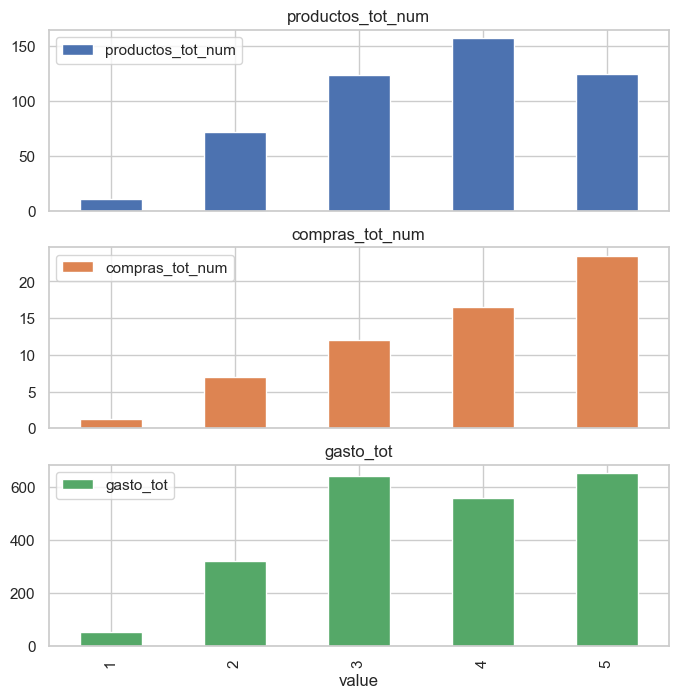

In [99]:
minicubo[minicubo.variable =='F'].set_index('value').plot.bar(subplots = True, figsize =(8,8));
plt.show()

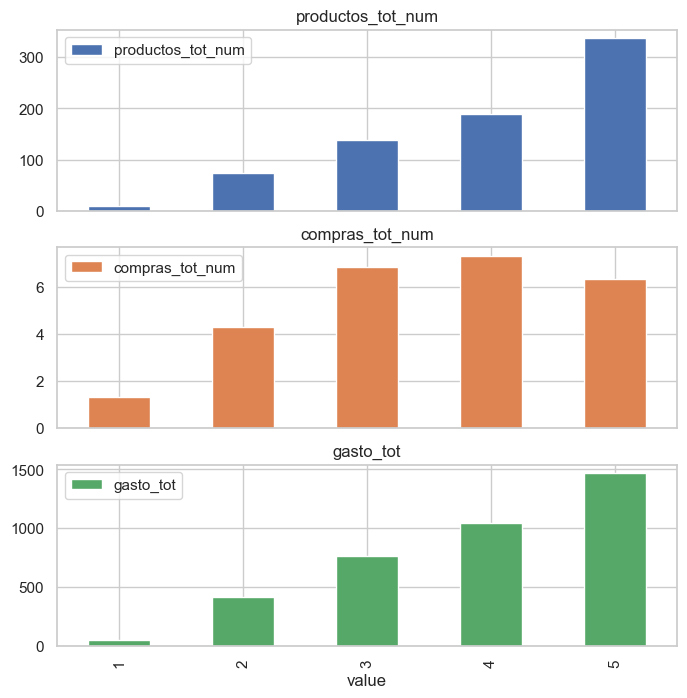

In [100]:
minicubo[minicubo.variable =='M'].set_index('value').plot.bar(subplots = True, figsize =(8,8));
plt.show()

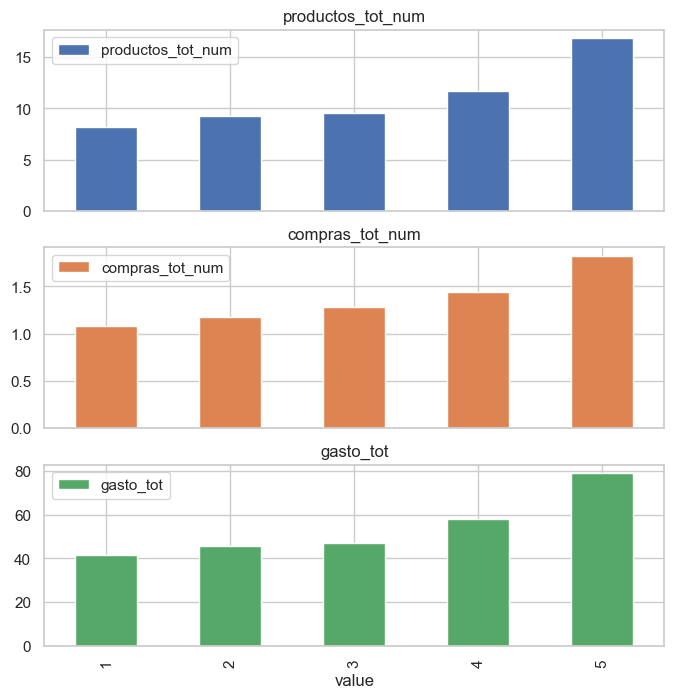

In [101]:
minicubo[minicubo.variable =='R'].set_index('value').plot.bar(subplots = True, figsize =(8,8));
plt.show()

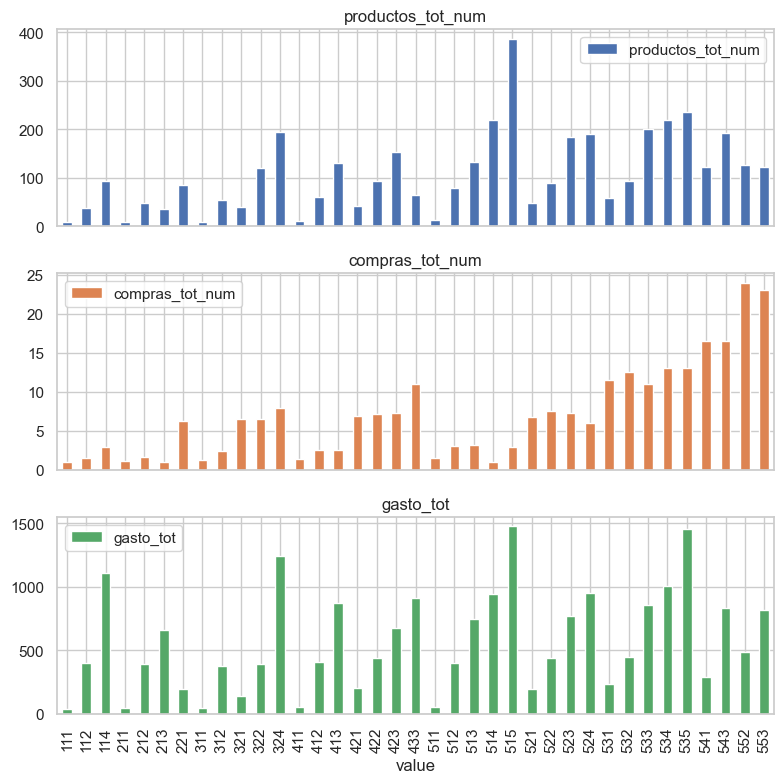

In [102]:
minicubo[minicubo.variable =='RFM'].set_index('value').plot.bar(subplots = True, figsize =(8,8));
plt.tight_layout()
plt.show();

## 1.5. Análisis de Portfolio de Productos: Optimización del catálogo

Construiremos el DF con la granularidad que necesitemos.

Vamos a seguir una metodología de 3 pasos: 
1. Agrupación por producto y evento y pasar los eventos a columnas.
2. Vamos a crear un maestro con el precio de cada producto, hemos visto que no varían.
3. Unir los dos DF y renombrarlo 

Vamos con el paso 1

In [103]:
prod = df.groupby(['producto','evento']).size()
prod

producto  evento          
3752      view                 10
3762      cart                127
          purchase             28
          remove_from_cart     59
          view                258
                             ... 
5932538   view                  1
5932540   cart                  1
          view                  2
5932578   view                  1
5932585   view                  2
Length: 137068, dtype: int64

Pasamos los eventos a columnas para analizarlos mejor.

In [104]:
prod = prod.unstack(level = 1).fillna(0)
prod

evento,cart,purchase,remove_from_cart,view
producto,,,,
3752,0.00,0.00,0.00,10.00
3762,127.00,28.00,59.00,258.00
3763,10.00,2.00,2.00,51.00
3771,0.00,0.00,0.00,9.00
3774,26.00,7.00,13.00,76.00
...,...,...,...,...
5932537,1.00,0.00,0.00,1.00
5932538,0.00,0.00,0.00,1.00
5932540,1.00,0.00,0.00,2.00


Fase 2, generamos el maestro de productos y precios y calculamos media de precio.

In [105]:
df.groupby('producto',as_index = False).precio.mean()

,producto,precio
0,3752,15.71
1,3762,19.29
2,3763,16.00
3,3771,15.08
4,3774,15.92
...,...,...
45322,5932537,1.43
45323,5932538,1.43
45324,5932540,1.43
45325,5932578,6.02


In [106]:
maestro_precios= df.groupby('producto',as_index = False).precio.mean()

Fase 3. Integrar, nos interesa integrarlos con merge por el campo clave producto.

Lo guardamos como prod

In [107]:
prod= pd.merge(left= prod, right = maestro_precios, how = 'left', on= 'producto')
prod

,producto,cart,purchase,remove_from_cart,view,precio
0,3752,0.00,0.00,0.00,10.00,15.71
1,3762,127.00,28.00,59.00,258.00,19.29
2,3763,10.00,2.00,2.00,51.00,16.00
3,3771,0.00,0.00,0.00,9.00,15.08
4,3774,26.00,7.00,13.00,76.00,15.92
...,...,...,...,...,...,...
45322,5932537,1.00,0.00,0.00,1.00,1.43
45323,5932538,0.00,0.00,0.00,1.00,1.43
45324,5932540,1.00,0.00,0.00,2.00,1.43
45325,5932578,0.00,0.00,0.00,1.00,6.02


Renombramos las columnas

In [108]:
prod = prod[['producto','view','cart','remove_from_cart','purchase','precio']]
prod

,producto,view,cart,remove_from_cart,purchase,precio
0,3752,10.00,0.00,0.00,0.00,15.71
1,3762,258.00,127.00,59.00,28.00,19.29
2,3763,51.00,10.00,2.00,2.00,16.00
3,3771,9.00,0.00,0.00,0.00,15.08
4,3774,76.00,26.00,13.00,7.00,15.92
...,...,...,...,...,...,...
45322,5932537,1.00,1.00,0.00,0.00,1.43
45323,5932538,1.00,0.00,0.00,0.00,1.43
45324,5932540,2.00,1.00,0.00,0.00,1.43
45325,5932578,1.00,0.00,0.00,0.00,6.02


Se inicia el análisis identificando los productos de mayor rotación

In [109]:
prod.sort_values('purchase', ascending = False) [0:20]

,producto,view,cart,remove_from_cart,purchase,precio
16807,5809910,9195.00,2796.00,1249.00,764.00,5.21
28178,5854897,624.00,2486.00,793.00,483.00,0.32
6644,5700037,1150.00,2603.00,716.00,361.00,0.40
314,5304,516.00,1184.00,426.00,341.00,0.32
9900,5751422,2204.00,1119.00,625.00,331.00,10.87
15394,5802432,701.00,2495.00,745.00,322.00,0.32
16809,5809912,3059.00,1352.00,863.00,321.00,5.19
18415,5815662,1219.00,1697.00,653.00,310.00,0.91
9862,5751383,2341.00,1035.00,550.00,298.00,10.24
14043,5792800,1527.00,911.00,512.00,285.00,10.25


Se presentan los productos más vendidos ordenados por volumen de transacciones.

Este ranking permite análisis cualitativo de patrones: categorización de productos, segmentación por público objetivo, etc.

Estos datos resultan especialmente valiosos para sistemas de recomendación dirigidos a nuevos clientes sin historial de compra.

A continuación se identifica el catálogo muerto (productos sin ventas).

In [110]:
prod[prod.purchase == 0]

,producto,view,cart,remove_from_cart,purchase,precio
0,3752,10.00,0.00,0.00,0.00,15.71
3,3771,9.00,0.00,0.00,0.00,15.08
6,3790,10.00,0.00,0.00,0.00,7.92
8,3809,2.00,0.00,0.00,0.00,12.54
9,3812,1.00,0.00,0.00,0.00,12.54
...,...,...,...,...,...,...
45322,5932537,1.00,1.00,0.00,0.00,1.43
45323,5932538,1.00,0.00,0.00,0.00,1.43
45324,5932540,2.00,1.00,0.00,0.00,1.43
45325,5932578,1.00,0.00,0.00,0.00,6.02


**INSIGHT #8**: Casi 22.000 productos no han tenido ninguna venta en los 5 meses analizados.

Este dato es muy importante porque parece que la mitad del catálogo no se vende al menos en los meses de análisis.

Requeriría una investigación, si no se venden porque no se ven, o que no son atractivos o interesantes para los clientes.

Podría llegarse a la acción de tener que reducir bastante el catálogo.

### Relación entre el precio de compra y las ventas de los productos

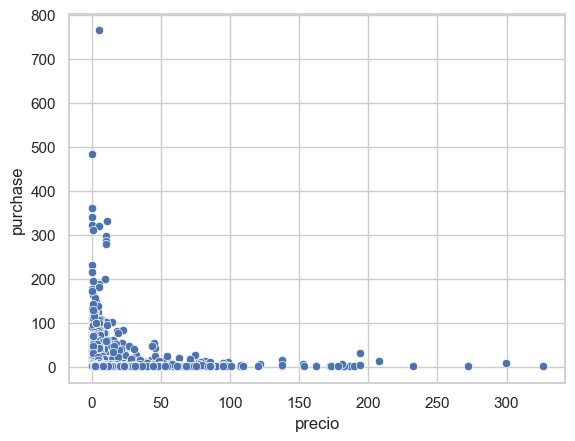

In [111]:
sns.scatterplot(data = prod[prod.purchase > 0], x= 'precio', y = 'purchase');

Se observa una relación inversa entre el precio y el volumen de compras.

Analicemos la relación en el rango de precio <50€

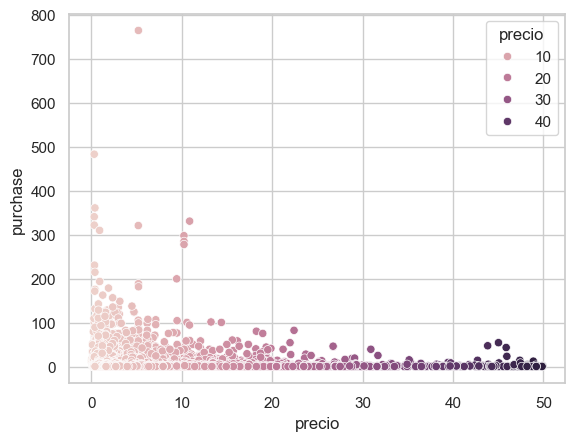

In [112]:
sns.scatterplot(data = prod[(prod.purchase > 0) &(prod.precio < 50)], x = 'precio', y = 'purchase', hue = 'precio');

Parece que la mayor relación la encontraremos ampliando el zoom por debajo de los 20€.

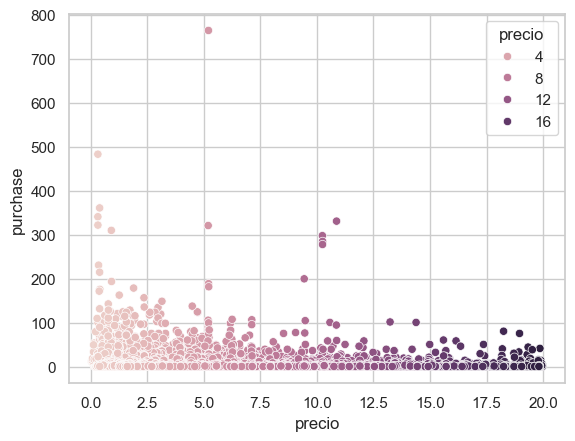

In [113]:
sns.scatterplot(data = prod[(prod.purchase > 0) &(prod.precio < 20)], x = 'precio', y = 'purchase', hue = 'precio');

**Conclusiones:**
- Si que existe sensibilidad de precios, donde los productos de menos precio se venden más.
- Este incremento de las ventas se produce por debajo de 5€.
- Se podría plantear una estrategia de venta cruzada, encadenar productos de bajo precio con algun relacionado de mayor precio.

### Análisis de abandono de carrito

Buscaremos si hay una categoria de productos que son abandonados o si hay alguno que luego sea sustituido y se saque del carrito

In [114]:
prod

,producto,view,cart,remove_from_cart,purchase,precio
0,3752,10.00,0.00,0.00,0.00,15.71
1,3762,258.00,127.00,59.00,28.00,19.29
2,3763,51.00,10.00,2.00,2.00,16.00
3,3771,9.00,0.00,0.00,0.00,15.08
4,3774,76.00,26.00,13.00,7.00,15.92
...,...,...,...,...,...,...
45322,5932537,1.00,1.00,0.00,0.00,1.43
45323,5932538,1.00,0.00,0.00,0.00,1.43
45324,5932540,2.00,1.00,0.00,0.00,1.43
45325,5932578,1.00,0.00,0.00,0.00,6.02


In [115]:
prod.insert(loc = 4, column = 'remove_from_cart_porc', value = prod.remove_from_cart / prod.cart *100)
prod

,producto,view,cart,remove_from_cart,remove_from_cart_porc,purchase,precio
0,3752,10.00,0.00,0.00,NaN,0.00,15.71
1,3762,258.00,127.00,59.00,46.46,28.00,19.29
2,3763,51.00,10.00,2.00,20.00,2.00,16.00
3,3771,9.00,0.00,0.00,NaN,0.00,15.08
4,3774,76.00,26.00,13.00,50.00,7.00,15.92
...,...,...,...,...,...,...,...
45322,5932537,1.00,1.00,0.00,0.00,0.00,1.43
45323,5932538,1.00,0.00,0.00,NaN,0.00,1.43
45324,5932540,2.00,1.00,0.00,0.00,0.00,1.43
45325,5932578,1.00,0.00,0.00,NaN,0.00,6.02


Cuando da nulos entendemos que no se han añadido a carrito, por lo que pondremos un filtro de número de veces que se ha añadido al más de 30 veces.

In [116]:
prod.loc[prod.cart> 30].sort_values('remove_from_cart_porc', ascending = False)[0:30]

,producto,view,cart,remove_from_cart,remove_from_cart_porc,purchase,precio
14330,5797131,26.00,38.00,136.00,357.89,7.00,4.43
37937,5893670,36.00,35.00,109.00,311.43,3.00,4.90
29128,5858481,41.00,31.00,64.00,206.45,7.00,4.55
16658,5809346,8.00,34.00,62.00,182.35,7.00,0.78
26120,5848412,34.00,37.00,66.00,178.38,12.00,0.79
37944,5893677,64.00,41.00,70.00,170.73,10.00,4.69
8416,5731470,39.00,34.00,58.00,170.59,10.00,6.32
3217,5635096,32.00,32.00,52.00,162.50,11.00,4.42
3244,5635127,41.00,32.00,52.00,162.50,10.00,4.43
21617,5830537,35.00,37.00,60.00,162.16,8.00,1.73


Nos salen porcentajes superiores a 100. Deberíamos revisar y volver a filtrar.

A continuación analizaríamos por ejemplo los que están por encima de 50 para ver si sacarlos de catálogo o mejorar su visualización, etc.

### Productos que se ven mucho pero se compran poco

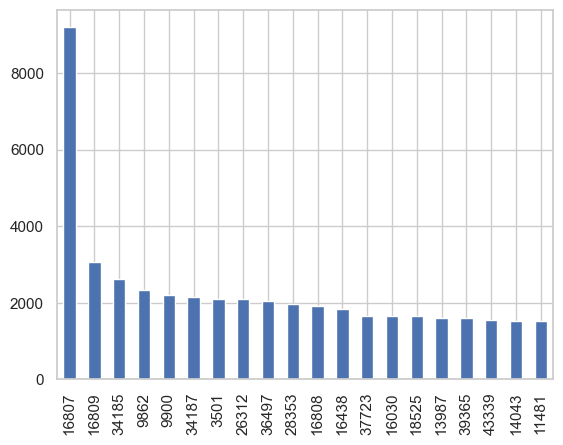

In [117]:
prod.view.sort_values(ascending = False) [0:20].plot.bar();

Hay un producto que con diferencia se ve mucho más.

Siguiente análisis es comparar esas visualizaciones con las compras a través de un scatter de seaborn.

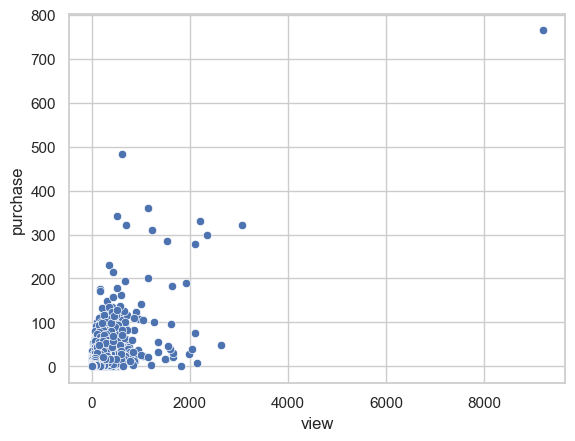

In [118]:
sns.scatterplot(data= prod, x= 'view', y = 'purchase');

Vamos a restringir ejes para eliminar el atípico.

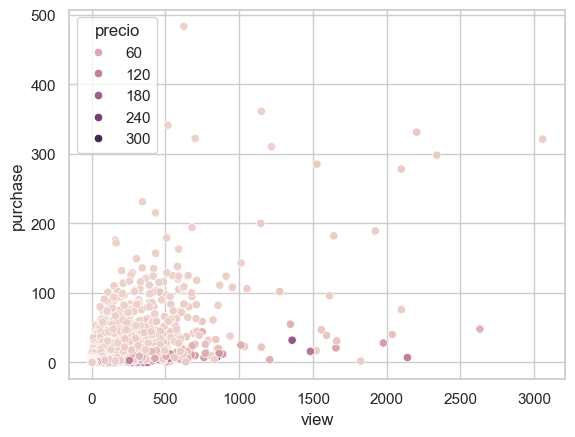

In [119]:
sns.scatterplot(data= prod.loc[prod.view < 4000], x= 'view', y = 'purchase', hue = 'precio');

Limitamos más

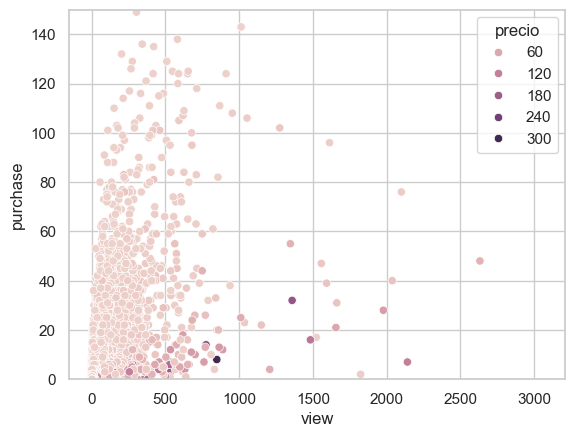

In [120]:
sns.scatterplot(data= prod.loc[prod.view < 4000], x= 'view', y = 'purchase', hue = 'precio');
plt.ylim(0,150);

Nos interesaría localizar los productos que tienen mas de 600 visualizaciones hasta 2500, pero tienen menos de 60 ventas.

Analizar por qué se compran poco y ver si posicionarlos mejor, añadirlos a newsletters, etc.

# 2. ALGORITMO DE RECOMENDACIÓN: Collaborative Filtering para venta cruzada

Implementación de un motor de recomendación basado en distancia euclídea entre vectores de compra para optimizar cross-selling y aumentar ticket medio.

In [121]:
df.usuario.nunique()

163765

Tenemos 163735 usuarios, por lo que los procesos de cálculos serán extensos. Con una matriz con 43000 productos.

Vamos a quedarnos entonces con los 100 productos más vendidos para reducir. Con los que hacemos una lista.

In [122]:
mas_vendidos = prod.sort_values('purchase', ascending = False).producto[0:100]
mas_vendidos

16807    5809910
28178    5854897
6644     5700037
314         5304
9900     5751422
          ...   
30395    5862564
9778     5749720
9732     5749149
22751    5835859
22116    5833335
Name: producto, Length: 100, dtype: int64

In [123]:
temp= df.loc[df.producto.isin(mas_vendidos)]
temp

,usuario,sesion,categoria,evento,producto,precio,date,año,mes,dia,hora,minuto,segundo,festivo,black_firday,san_valentin
fecha,,,,,,,,,,,,,,,,
2019-10-01 00:26:49,536128518,a31f0991-645e-4472-a012-95eb2f814568,1487580006317032337,purchase,5815662,0.92,2019-10-01,2019,10,1,0,26,49,0,0,0
2019-10-01 00:46:20,555415545,b9cc1771-9062-4e08-a3ad-363314cd17d8,1602943681873052386,view,5809912,5.24,2019-10-01,2019,10,1,0,46,20,0,0,0
2019-10-01 00:48:13,555415545,b9cc1771-9062-4e08-a3ad-363314cd17d8,1602943681873052386,view,5816170,5.24,2019-10-01,2019,10,1,0,48,13,0,0,0
2019-10-01 00:52:39,555415545,b9cc1771-9062-4e08-a3ad-363314cd17d8,1487580005092295511,view,5815730,10.95,2019-10-01,2019,10,1,0,52,39,0,0,0
2019-10-01 01:33:26,555456891,b3239dc3-f107-4034-a507-4c41f646e38a,1487580005092295511,view,5849033,10.32,2019-10-01,2019,10,1,1,33,26,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-02-29 23:11:44,615102046,17b94398-0397-4c59-bc84-fe91dde0a8ec,1487580006509970331,cart,5793703,2.22,2020-02-29,2020,2,29,23,11,44,0,0,0
2020-02-29 23:12:40,615102046,17b94398-0397-4c59-bc84-fe91dde0a8ec,2195085255034011676,cart,5550302,1.21,2020-02-29,2020,2,29,23,12,40,0,0,0
2020-02-29 23:12:50,599909613,1c6c708d-135d-487b-afa9-4bbcfd28db4d,1602943681873052386,cart,5809911,5.24,2020-02-29,2020,2,29,23,12,50,0,0,0


In [124]:
df

,usuario,sesion,categoria,evento,producto,precio,date,año,mes,dia,hora,minuto,segundo,festivo,black_firday,san_valentin
fecha,,,,,,,,,,,,,,,,
2019-10-01 00:01:46,462033176,a18e0999-61a1-4218-8f8f-61ec1d375361,1487580005092295511,view,5843665,9.44,2019-10-01,2019,10,1,0,1,46,0,0,0
2019-10-01 00:01:55,514753614,e2fecb2d-22d0-df2c-c661-15da44b3ccf1,1487580013069861041,cart,5868461,3.57,2019-10-01,2019,10,1,0,1,55,0,0,0
2019-10-01 00:02:50,527418424,86e77869-afbc-4dff-9aa2-6b7dd8c90770,1487580006300255120,view,5877456,122.22,2019-10-01,2019,10,1,0,2,50,0,0,0
2019-10-01 00:03:41,555448072,b5f72ceb-0730-44de-a932-d16db62390df,1487580013749338323,view,5649270,6.19,2019-10-01,2019,10,1,0,3,41,0,0,0
2019-10-01 00:03:44,552006247,2d8f304b-de45-4e59-8f40-50c603843fe5,1487580005411062629,view,18082,16.03,2019-10-01,2019,10,1,0,3,44,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-02-29 23:58:49,147995998,5ff96629-3627-493e-a25b-5a871ec78c90,1487580006317032337,cart,5815662,0.92,2020-02-29,2020,2,29,23,58,49,0,0,0
2020-02-29 23:58:57,147995998,5ff96629-3627-493e-a25b-5a871ec78c90,1487580006317032337,view,5815665,0.59,2020-02-29,2020,2,29,23,58,57,0,0,0
2020-02-29 23:59:05,147995998,5ff96629-3627-493e-a25b-5a871ec78c90,1487580006317032337,cart,5815665,0.59,2020-02-29,2020,2,29,23,59,5,0,0,0


Vemos que tenemos un elemento de 168000 registros por 16 columnas, mientas que en Df tenemos 2 millones de registros.

Vamos a construir la matriz de usuario-item definitiva.

Agregando por usuario y producto que es lo que nos interesa.

In [125]:
temp.loc[temp.evento =='purchase'].groupby(['usuario','producto']).size().unstack(level = 1)

producto,4497,4600,4768,4938,4958,5013,5304,5526,5528034,5528035,...,5848909,5849033,5854812,5854897,5855332,5857007,5857360,5862564,5862943,5889300
usuario,,,,,,,,,,,,,,,,,,,,,
25392526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50748978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN
74332980,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80577370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88211255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
621646584,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
621788730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN
621925941,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ahora ya tenemos una matriz de 5000 usuarios.

Es una matriz dispersa (sparse).

Reemplazamos por 0 todos los NA y la guardamos como usuari_item

In [126]:
usuario_item = temp.loc[temp.evento =='purchase'].groupby(['usuario','producto']).size().unstack(level = 1).fillna(0)
usuario_item

producto,4497,4600,4768,4938,4958,5013,5304,5526,5528034,5528035,...,5848909,5849033,5854812,5854897,5855332,5857007,5857360,5862564,5862943,5889300
usuario,,,,,,,,,,,,,,,,,,,,,
25392526,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50748978,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
74332980,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
80577370,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
88211255,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
621646584,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
621788730,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
621925941,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


PASO 1 REALIZADO = CONSTRUIR MATRIZ

PASO 2 CALCULAR DISTANCIA EUCLÍDEA

Podemos usar el spatial de scipy.

In [127]:
from scipy import spatial

La funcióon va a ir recorriendo toda la matriz por cada producto, es decir, por cada vector vertical, comparando cada vector y su distancia.

Una vez que llega al final empieza a comparar el siguiente producto con todos los demás.

In [128]:
def recomendador(dataframe):
    def distancia(producto):
        return(dataframe.apply(lambda x: spatial.distance.euclidean(x,producto)))
    return(dataframe.apply(lambda x: distancia(x)))

In [129]:
item_item = recomendador(usuario_item)
item_item

producto,4497,4600,4768,4938,4958,5013,5304,5526,5528034,5528035,...,5848909,5849033,5854812,5854897,5855332,5857007,5857360,5862564,5862943,5889300
producto,,,,,,,,,,,,,,,,,,,,,
4497,0.00,14.42,14.49,15.62,15.91,17.58,23.39,15.23,16.16,20.30,...,15.72,24.45,14.97,26.10,15.30,15.07,15.78,15.17,16.40,15.33
4600,14.42,0.00,10.68,14.49,14.59,16.46,22.69,13.93,14.87,19.70,...,14.39,23.87,13.49,25.75,13.78,13.60,14.46,13.86,14.73,13.89
4768,14.49,10.68,0.00,14.56,14.73,16.28,22.74,14.00,14.93,19.75,...,14.18,24.00,13.27,25.63,13.86,13.75,14.39,13.86,14.80,14.11
4938,15.62,14.49,14.56,0.00,15.52,16.03,22.96,14.76,15.65,20.25,...,15.13,24.17,14.35,25.87,14.76,14.59,15.46,14.97,15.72,15.13
4958,15.91,14.59,14.73,15.52,0.00,17.49,22.27,15.33,15.81,20.32,...,15.49,24.35,14.66,26.15,14.87,14.97,15.94,15.26,16.12,15.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5857007,15.07,13.60,13.75,14.59,14.97,16.79,22.80,14.59,15.10,19.62,...,14.49,23.98,13.89,25.61,14.32,0.00,14.83,14.46,15.17,14.42
5857360,15.78,14.46,14.39,15.46,15.94,16.06,23.24,15.39,16.12,20.32,...,15.43,23.85,14.73,25.46,15.20,14.83,0.00,13.75,16.19,15.43
5862564,15.17,13.86,13.86,14.97,15.26,15.72,22.91,14.70,15.39,19.90,...,15.00,23.32,14.00,25.12,14.35,14.46,13.75,0.00,15.39,14.66


**Algoritmo de Collaborative Filtering - Distancia Euclídea**

1. **Entrada**: Array de IDs de productos seleccionados por el usuario
2. **Cálculo de similitud**: Distancia euclídea entre vectores de compra en la matriz item-item
3. **Filtrado**: Se excluyen los productos ya considerados (para evitar recomendaciones redundantes)
4. **Salida**: Top 10 productos más similares ordenados por distancia mínima

In [130]:
productos = '4497;5857007'
array = np.int64(productos.split(';'))
array

array([   4497, 5857007])

Se genera un array de integers que representa los IDs de producto.

**Paso 2 - Extracción de vectores**: Se filtra la matriz item-item para obtener los vectores correspondientes a los productos seleccionados

In [131]:
productos = '4497;5857007;5862943'

matriz= item_item
array = np.int64(productos.split(';'))
matriz = matriz[array]
matriz

producto,4497,5857007,5862943
producto,,,
4497,0.00,15.07,16.40
4600,14.42,13.60,14.73
4768,14.49,13.75,14.80
4938,15.62,14.59,15.72
4958,15.91,14.97,16.12
...,...,...,...
5857007,15.07,0.00,15.17
5857360,15.78,14.83,16.19
5862564,15.17,14.46,15.39


**Paso 3 - Agregación de similitudes**: Se suma la distancia euclídea de cada producto candidato respecto a todos los productos seleccionados.

Los productos con menor distancia acumulada son los más similares al patrón de compra del usuario.

In [132]:
productos = '4497;5857007;5862943'

matriz= item_item
array = np.int64(productos.split(';'))
matriz = matriz[array]

#Añadimos el calculo de las distancias
suma_distancias = matriz.agg(sum,axis = 1)

suma_distancias

producto
4497                31.47
4600                42.75
4768                43.04
4938                45.93
4958                47.00
                ...      
5857007             30.23
5857360             46.80
5862564             45.02
5862943             31.57
5889300             44.98
Length: 100, dtype: float64

El producto 5857007 presenta la distancia acumulada mínima respecto al patrón observado, por lo que constituye la recomendación de mayor confianza.

**Paso 4 - Exclusión de productos conocidos**: Se filtran los productos ya seleccionados mediante operador booleano negativo (~isin) para evitar redundancias.

In [133]:
def priorizador(matriz, productos,devuelve = 10):

    array = np.int64(productos.split(';'))
    matriz = matriz[array]
    
    suma_distancias = matriz.agg(sum,axis = 1)
    
    sum_distancias = suma_distancias.loc[~suma_distancias.index.isin(list(array))]
    
    return (suma_distancias.sort_values() [0:devuelve])

Se optimiza la función integrando directamente la matriz `item_item` para acceso más eficiente

In [134]:
def priorizador(productos,devuelve = 10):
    # crear array con productos de entrada
    array = np.int64(productos.split(';'))
    
    #extraer sus vectores de la matriz total
    matriz = item_item[array]

    #calcular la suma de distancias    
    suma_distancias = matriz.agg(sum,axis = 1)

    # Eliminar los productos input
    suma_distancias = suma_distancias.loc[~suma_distancias.index.isin(list(array))]

    # Devolver los 10 productos con menos distancia
    return (suma_distancias.sort_values() [0:devuelve])

Y ahora probamos la función con un producto

In [135]:
priorizador ('4497')

producto
5724230             14.39
4600                14.42
5550302             14.49
4768                14.49
5749149             14.56
5833318             14.63
5824810             14.70
5835859             14.70
5809303             14.73
5833335             14.73
dtype: float64

In [136]:
# Si ha visto esos tres productos pero el hueco solo permite anunciar 5:
priorizador('4497;5857007;5862943', devuelve = 5)

producto
5833335             42.14
5749149             42.47
5833318             42.47
5550302             42.54
5809303             42.58
dtype: float64

# 3. CONCLUSIONES Y PLAN DE ACCIÓN: Estrategia CRO (Conversion Rate Optimization)

## Síntesis de insights clave

La tendencia actual es plana en todas las métricas, confirmando la necesidad de implementar un plan CRO estructurado. Tras el análisis exhaustivo de 2M+ eventos, se han identificado **12 iniciativas concretas** organizadas en **5 palancas de negocio**, con potencial de incremento significativo en ingresos.

## 3.1. Baseline: Métricas actuales de negocio (Oct 2019 - Feb 2020)

**Comportamiento del usuario:**
- Media de visualizaciones por sesión: 2.2 productos
- Tasa de adición a carrito: 60% (sobre visualizaciones)
- Tasa de abandono de carrito: 71.42%
- Tasa de conversión final: 22% (compra sobre carrito)

**Características del cliente:**
- Mediana de productos por compra: 5 productos
- Clientes con compra recurrente: 10% (CRITICAL - INSIGHT #6)
- Precio medio por producto: €14-20 (sensibilidad a precio)

**Métricas de negocio:**
- Facturación media mensual: €125,000
- Productos sin venta (muertos en catálogo): ~22,000 (50% del catálogo)
- Margen de mejora en frecuencia de compra: 90% potencial

## 3.2. Palanca 1: Incremento de visualizaciones y tráfico (Awareness)

**Objetivo:** Aumentar el volumen de eventos de visualización de producto

**Acciones:**
1. Revisar campañas de paid (generación y retargeting) para concentrar inversión en franjas horarias de pico (9-13h, 18-20h)
2. Optimizar inversión de períodos navideños y post-navideños enfocados en Black Friday
3. Incrementar inversión hasta alcanzar CPA máximo basado en LTV calculado

## 3.3. Palanca 2: Optimización de tasa de conversión (Conversion)

**Objetivo:** Mejorar la transformación de visualizaciones en compras (actualmente 13%)

**Acciones:**
4. Preconfiguraciones de home con productos "must-see" identificados en análisis (most viewed + most sold)
5. Optimizar productos con alta tasa de abandono de carrito (análisis de barreras)
6. Implementar mejoras UX en productos con alto tráfico pero baja conversión (análisis view/purchase ratio)

## 3.4. Palanca 3: Aumento de venta cruzada (Cross-Selling)

**Objetivo:** Incrementar valor de ticket medio y productos por compra (actualmente 5)

**Acciones:**
7. Analizar correlaciones entre productos: "quién compra X también compra Y"
8. Desplegar motor de recomendación en tiempo real en puntos críticos del purchase journey (PDP, cart, checkout)
9. Objetivo: Llevar mediana de 5 a 7+ productos por compra = +20-40% en ticket medio

## 3.5. Palanca 4: Incremento de frecuencia de compra (Retention)

**Objetivo:** Reducir el 90% de churn de nuevos clientes tras primer mes

**Acciones:**
10. Estrategia de re-engagement: Newsletter automática con recomendaciones personalizadas basadas en primera compra
11. Implementar campañas promocionales segmentadas para clientes RFM "At-Risk" (Recency baja)
12. Crear flujo de nurturing automático post-compra para mejorar supervivencia de cohortes

## 3.6. Palanca 5: Programa de fidelización (Loyalty)

**Objetivo:** Maximizar LTV de clientes de alto valor

**Acción:**
13. Programa VIP segmentado por RFM score: Beneficios diferenciados para clientes High-Value (RFM = 555), Medium-Value (RFM = 3-4 en cada dimensión), Growth (clientes recientes con potencial)

---

## 3.7. Impacto esperado

Con la implementación del plan CRO completo, se estima un incremento de **+25-40%** en ingresos mensuales (conservador), derivado de:
- +5-10% en conversión (acciones 4-6)
- +20-40% en ticket medio (acciones 7-9)  
- +10-15% en recurrencia (acciones 10-13)

**ROI esperado: 3-5x en 6 meses** (según benchmark de industria)